##Premier League Machine Learning Model
### Danial N., Adam S., Alexa W.

###Connect Colab to your Drive:

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


###Each user must specify their personal file path:

In [ ]:
import os

# TODO: Fill in the Google Drive path where you uploaded the assignment, it should be under CS3540/CS3540-Assignments/yournetid-A4
ALEXA = 'UVM/Undergrad/Year 4/Semester 2/CSML - Advanced Machine Learning/Colab Notebooks/'
ADAM = 'CS3540' # change this directory to yours
DAN = 'CS3540'
GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = ALEXA # Change to your name before running
GOOGLE_DRIVE_PATH = os.path.join('drive', 'MyDrive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))

['Assignment 1', 'Assignment 2', 'Assignment 3', 'decision_trees.ipynb', 'Assignment 4', 'Premier Project', 'Assignment 5', 'Assignment 6', 'multilayer_perceptron_example_in_class.ipynb', 'Assignment 7']


###Import/load all necessary modules and utilities:

In [ ]:
# import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn utilities
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler

# sklearn models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler

# Varying types of visualizations from decision_tree.ipynb
from sklearn.tree import export_graphviz # may need to pip install graphviz
from graphviz import Source # may need to pip install graphviz
from matplotlib.colors import ListedColormap

# used in assignment 3 with logistic regression / non-linear logistic regression
from past.builtins import xrange
from scipy.special import expit

%matplotlib inline

# import API requests and JSON handling
import requests, json
from pprint import pprint


In [ ]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

###Helpful Source for Loading in JSON File:
https://medium.com/analytics-vidhya/getting-started-with-fantasy-premier-league-data-56d3b9be8c32

##Import FPL API Bootstrap Data
### Main URL for all premier league players, teams, global gameweek summaries
#### Current Season: 2025/26


In [ ]:
# define base url for FPL API endpoints
#https://fantasy.premierleague.com/api/bootstrap-static/
base_url = 'https://fantasy.premierleague.com/api/'

# retireve JSON data from bootstrap-static endpoint for previous and current season
bootstrap_2223 = requests.get('https://web.archive.org/web/20230530110013/https://fantasy.premierleague.com/api/bootstrap-static/').json() # May 30 using Wayback Machine
bootstrap_2324 = requests.get('https://web.archive.org/web/20240522000017/https://fantasy.premierleague.com/api/bootstrap-static/').json() # May 22 using Wayback Machine
bootstrap_2425 = requests.get('https://web.archive.org/web/20250526110039/https://fantasy.premierleague.com/api/bootstrap-static/').json() # May 26 using Wayback Machine
bootstrap_2526 = requests.get(base_url+'bootstrap-static/').json()

# display headings for data
print(list(bootstrap_2526))

['chips', 'events', 'game_settings', 'game_config', 'phases', 'teams', 'total_players', 'element_stats', 'element_types', 'elements']


## Retrieve Player Data from Bootstrap API


In [ ]:
# elements contains data for each player
elements_2223 = bootstrap_2223['elements']
elements_2324 = bootstrap_2324['elements']
elements_2425 = bootstrap_2425['elements']
elements_2526 = bootstrap_2526['elements']

# load into DataFrame
players_2223 = pd.json_normalize(elements_2223)
players_2324 = pd.json_normalize(elements_2324)
players_2425 = pd.json_normalize(elements_2425)
players_2526 = pd.json_normalize(elements_2526)

# display headers of player data
print(list(players_2526.columns))

# display some data of players
display(players_2425[['id', 'web_name', 'team', 'total_points', 'team', 'element_type']].head())
print('-------------------------------------------------------------')
display(players_2526[['id', 'web_name', 'team', 'total_points', 'team', 'element_type']].head())
#As seen here the infromation about each player can be dificult to read as the team and position information is stored as ids

['can_transact', 'can_select', 'chance_of_playing_next_round', 'chance_of_playing_this_round', 'code', 'cost_change_event', 'cost_change_event_fall', 'cost_change_start', 'cost_change_start_fall', 'price_change_percent', 'dreamteam_count', 'element_type', 'ep_next', 'ep_this', 'event_points', 'first_name', 'form', 'id', 'in_dreamteam', 'news', 'news_added', 'now_cost', 'photo', 'points_per_game', 'removed', 'second_name', 'selected_by_percent', 'special', 'squad_number', 'status', 'team', 'team_code', 'total_points', 'transfers_in', 'transfers_in_event', 'transfers_out', 'transfers_out_event', 'value_form', 'value_season', 'web_name', 'known_name', 'region', 'team_join_date', 'birth_date', 'has_temporary_code', 'opta_code', 'minutes', 'goals_scored', 'assists', 'clean_sheets', 'goals_conceded', 'own_goals', 'penalties_saved', 'penalties_missed', 'yellow_cards', 'red_cards', 'saves', 'bonus', 'bps', 'influence', 'creativity', 'threat', 'ict_index', 'clearances_blocks_interceptions', 're

,id,web_name,team,total_points,team,element_type
0,1,Fábio Vieira,1,0,1,3
1,2,G.Jesus,1,42,1,4
2,3,Gabriel,1,117,1,2
3,4,Havertz,1,97,1,4
4,5,Hein,1,0,1,1


-------------------------------------------------------------


,id,web_name,team,total_points,team,element_type
0,1,Raya,1,141,1,1
1,2,Arrizabalaga,1,0,1,1
2,3,Hein,1,0,1,1
3,4,Setford,1,0,1,1
4,5,Gabriel,1,185,1,2


## Retrieve Team Data from Bootstrap API

In [ ]:
# teams contains data on each team
teams_2223 = bootstrap_2223['teams']
teams_2324 = bootstrap_2324['teams']
teams_2425 = bootstrap_2425['teams']
teams_2526 = bootstrap_2526['teams']

# load into DataFrame
clubs_2223 = pd.json_normalize(teams_2223)
clubs_2324 = pd.json_normalize(teams_2324)
clubs_2425 = pd.json_normalize(teams_2425)
clubs_2526 = pd.json_normalize(teams_2526)

# display headers of team data
print(list(clubs_2526.columns))

# display some data of teams
pd.set_option('display.max_columns', None)
display(clubs_2425.head())
print('-------------------------------------------------------------')
display(clubs_2526.head())

['code', 'draw', 'form', 'id', 'loss', 'name', 'played', 'points', 'position', 'short_name', 'strength', 'team_division', 'unavailable', 'win', 'strength_overall_home', 'strength_overall_away', 'strength_attack_home', 'strength_attack_away', 'strength_defence_home', 'strength_defence_away', 'pulse_id']


,code,draw,form,id,loss,name,played,points,position,short_name,strength,team_division,unavailable,win,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
0,3,0,None,1,0,Arsenal,0,0,2,ARS,5,None,False,0,1350,1350,1390,1400,1310,1300,1
1,7,0,None,2,0,Aston Villa,0,0,6,AVL,3,None,False,0,1145,1240,1130,1180,1160,1300,2
2,91,0,None,3,0,Bournemouth,0,0,9,BOU,3,None,False,0,1170,1200,1120,1180,1220,1220,127
3,94,0,None,4,0,Brentford,0,0,10,BRE,3,None,False,0,1130,1180,1100,1100,1160,1260,130
4,36,0,None,5,0,Brighton,0,0,8,BHA,3,None,False,0,1140,1165,1090,1140,1190,1190,131


-------------------------------------------------------------


,code,draw,form,id,loss,name,played,points,position,short_name,strength,team_division,unavailable,win,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
0,3,0,None,1,0,Arsenal,0,0,1,ARS,5,None,False,0,1305,1355,1340,1390,1270,1320,1
1,7,0,None,2,0,Aston Villa,0,0,5,AVL,3,None,False,0,1135,1230,1120,1210,1150,1250,2
2,90,0,None,3,0,Burnley,0,0,19,BUR,2,None,False,0,975,1045,910,1050,1040,1040,43
3,91,0,None,4,0,Bournemouth,0,0,7,BOU,3,None,False,0,1150,1235,1060,1230,1240,1240,127
4,94,0,None,5,0,Brentford,0,0,9,BRE,3,None,False,0,1135,1215,1120,1160,1150,1270,130


## Retrieve Postion Data from Bootstrap API

In [ ]:
# element_types contains data on each position
element_types_2223 = bootstrap_2223['element_types']
element_types_2324 = bootstrap_2324['element_types']
element_types_2425 = bootstrap_2425['element_types']
element_types_2526 = bootstrap_2526['element_types']

# load into DataFrame
positions_2223 = pd.json_normalize(element_types_2223)
positions_2324 = pd.json_normalize(element_types_2324)
positions_2425 = pd.json_normalize(element_types_2425)
positions_2526 = pd.json_normalize(element_types_2526)

# display headers of position data
print(list(positions_2526.columns))

# display some data of positions
display(positions_2425.head())
print('-------------------------------------------------------------')
display(positions_2526.head())

['id', 'plural_name', 'plural_name_short', 'singular_name', 'singular_name_short', 'squad_select', 'squad_min_select', 'squad_max_select', 'squad_min_play', 'squad_max_play', 'ui_shirt_specific', 'sub_positions_locked', 'element_count']


,id,plural_name,plural_name_short,singular_name,singular_name_short,squad_select,squad_min_select,squad_max_select,squad_min_play,squad_max_play,ui_shirt_specific,sub_positions_locked,element_count
0,1,Goalkeepers,GKP,Goalkeeper,GKP,2,None,None,1,1,True,[12],82
1,2,Defenders,DEF,Defender,DEF,5,None,None,3,5,False,[],268
2,3,Midfielders,MID,Midfielder,MID,5,None,None,2,5,False,[],347
3,4,Forwards,FWD,Forward,FWD,3,None,None,1,3,False,[],87
4,5,Managers,MNG,Manager,MNG,0,None,None,0,0,True,[],20


-------------------------------------------------------------


,id,plural_name,plural_name_short,singular_name,singular_name_short,squad_select,squad_min_select,squad_max_select,squad_min_play,squad_max_play,ui_shirt_specific,sub_positions_locked,element_count
0,1,Goalkeepers,GKP,Goalkeeper,GKP,2,None,None,1,1,True,[12],96
1,2,Defenders,DEF,Defender,DEF,5,None,None,3,5,False,[],268
2,3,Midfielders,MID,Midfielder,MID,5,None,None,2,5,False,[],373
3,4,Forwards,FWD,Forward,FWD,3,None,None,1,3,False,[],93


## Merge Player DataFrame with Team and Position DataFrame to display id's Interms of Actual Team and Position Names

In [ ]:
# rename headers in player, team and position tabels prior to merging
players_data_2223 = players_2223.rename(columns={'id':'player_id'})
players_data_2324 = players_2324.rename(columns={'id':'player_id'})
players_data_2425 = players_2425.rename(columns={'id':'player_id'})
players_data_2526 = players_2526.rename(columns={'id':'player_id'})

clubs_data_2223= clubs_2223.rename(columns={'id':'team_id', 'name':'team_name'})
clubs_data_2324 = clubs_2324.rename(columns={'id':'team_id', 'name':'team_name'})
clubs_data_2425 = clubs_2425.rename(columns={'id':'team_id', 'name':'team_name'})
clubs_data_2526 = clubs_2526.rename(columns={'id':'team_id', 'name':'team_name'})

positions_data_2223 = positions_2223.rename(columns={'id':'position_id', 'singular_name_short':'position_name'})
positions_data_2324 = positions_2324.rename(columns={'id':'position_id', 'singular_name_short':'position_name'})
positions_data_2425 = positions_2425.rename(columns={'id':'position_id', 'singular_name_short':'position_name'})
positions_data_2526 = positions_2526.rename(columns={'id':'position_id', 'singular_name_short':'position_name'})

# build previous season DataFrames
# map team data
playerInfo_2223 = pd.merge(
    left = players_data_2223,
    right = clubs_data_2223,
    left_on = 'team',
    right_on = 'team_id')

# map position data
playerInfo_2223 = playerInfo_2223.merge(
    positions_data_2223,
    left_on='element_type',
    right_on='position_id')

# map team data
playerInfo_2324 = pd.merge(
    left = players_data_2324,
    right = clubs_data_2324,
    left_on = 'team',
    right_on = 'team_id')

# map position data
playerInfo_2324 = playerInfo_2324.merge(
    positions_data_2324,
    left_on='element_type',
    right_on='position_id')

# map team data
playerInfo_2425 = pd.merge(
    left = players_data_2425,
    right = clubs_data_2425,
    left_on = 'team',
    right_on = 'team_id')

# map position data
playerInfo_2425 = playerInfo_2425.merge(
    positions_data_2425,
    left_on='element_type',
    right_on='position_id')

# build current season DataFrames
# map team data
playerInfo_2526 = pd.merge(
    left = players_data_2526,
    right = clubs_data_2526,
    left_on = 'team',
    right_on = 'team_id')

# map position data
playerInfo_2526 = playerInfo_2526.merge(
    positions_data_2526,
    left_on='element_type',
    right_on='position_id')


# display new DataFrames
display(playerInfo_2425[['player_id', 'web_name', 'team_id', 'team_name', 'position_id', 'position_name']].head())
print('-------------------------------------------------------------')
display(playerInfo_2526[['player_id','web_name', 'team_id', 'team_name', 'position_id', 'position_name']].head())

,player_id,web_name,team_id,team_name,position_id,position_name
0,1,Fábio Vieira,1,Arsenal,3,MID
1,2,G.Jesus,1,Arsenal,4,FWD
2,3,Gabriel,1,Arsenal,2,DEF
3,4,Havertz,1,Arsenal,4,FWD
4,5,Hein,1,Arsenal,1,GKP


-------------------------------------------------------------


,player_id,web_name,team_id,team_name,position_id,position_name
0,1,Raya,1,Arsenal,1,GKP
1,2,Arrizabalaga,1,Arsenal,1,GKP
2,3,Hein,1,Arsenal,1,GKP
3,4,Setford,1,Arsenal,1,GKP
4,5,Gabriel,1,Arsenal,2,DEF


##Import FPL API Gameweek History Data for Current Season

In [ ]:
def gameweek_history(player_id):
    '''get all gameweek info for a given player_id
    source: https://medium.com/analytics-vidhya/getting-started-with-fantasy-premier-league-data-56d3b9be8c32'''

    # send GET request to
    # https://fantasy.premierleague.com/api/element-summary/{PID}/
    gameweek_2526 = requests.get( base_url + 'element-summary/' + str(player_id) + '/').json()

    # history contains data for each gameweek
    history_2526 = gameweek_2526['history']

    # load into DataFrame
    gw_history_2526 = pd.json_normalize(history_2526)

    return gw_history_2526

# create empty list to store gameweek history for all players
all_gw_2526 = []

# loop through all player ids to get gameweek history data
for player_id in list(playerInfo_2526['player_id']):
  # get current player gameweek history DataFrame
  df = gameweek_history(player_id)

  # get player web name and id for current player id
  player_info = playerInfo_2526[playerInfo_2526['player_id'] == player_id].iloc[0]
  df['player_id'] = player_info['player_id']
  df['web_name'] = player_info['web_name']

  # append DataFrame to list
  all_gw_2526.append(df)

# combine all players data into one DataFrame
points_history_2526 = pd.concat(all_gw_2526, ignore_index=True) # reset indicies

# display headers of data
print(list(points_history_2526))

# display part of data
points_history_2526[['round', 'player_id', 'web_name', 'total_points']].head()

['element', 'fixture', 'opponent_team', 'total_points', 'was_home', 'kickoff_time', 'team_h_score', 'team_a_score', 'round', 'modified', 'minutes', 'goals_scored', 'assists', 'clean_sheets', 'goals_conceded', 'own_goals', 'penalties_saved', 'penalties_missed', 'yellow_cards', 'red_cards', 'saves', 'bonus', 'bps', 'influence', 'creativity', 'threat', 'ict_index', 'clearances_blocks_interceptions', 'recoveries', 'tackles', 'defensive_contribution', 'starts', 'expected_goals', 'expected_assists', 'expected_goal_involvements', 'expected_goals_conceded', 'value', 'transfers_balance', 'selected', 'transfers_in', 'transfers_out', 'player_id', 'web_name']


,round,player_id,web_name,total_points
0,1,1,Raya,10
1,2,1,Raya,6
2,3,1,Raya,2
3,4,1,Raya,6
4,5,1,Raya,2


## Create Local Clone of Git Repository Containing Previous Seasons Data

In [ ]:
# this is one of the most popular githubs for FPL data collection
!git clone https://github.com/vaastav/Fantasy-Premier-League.git

Cloning into 'Fantasy-Premier-League'...
remote: Enumerating objects: 413791, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 413791 (delta 0), reused 0 (delta 0), pack-reused 413790 (from 2)
Receiving objects: 100% (413791/413791), 174.34 MiB | 17.42 MiB/s, done.
Resolving deltas: 100% (214914/214914), done.
Updating files: 100% (17481/17481), done.


## Store FPL Previous Season Gameweek History Data for Each Player

In [ ]:
# define base url for acessing players data from previous season (20/21 and 21/22 season do not have XG and XA stats)
#base_path_2021 = './Fantasy-Premier-League/data/2020-21/players/'
#base_path_2122 = './Fantasy-Premier-League/data/2021-22/players/'
base_path_2223 = './Fantasy-Premier-League/data/2022-23/players/'
base_path_2324 = './Fantasy-Premier-League/data/2023-24/players/'
base_path_2425 = './Fantasy-Premier-League/data/2024-25/players/'

# create empty list to store gameweek history for all players
#all_gw_2021= []
#all_gw_2122= []
all_gw_2223= []
all_gw_2324 = []
all_gw_2425 = []

def prev_gameweek_history(base_path, list):
  # loop through each players folder
  for folder in os.listdir(base_path):
      folder_path = os.path.join(base_path, folder) # define path to folder ex folder name.) Aaron_Anselmino_774
      gw_file = os.path.join(folder_path, 'gw.csv') # acsess gw.csv that stores data from each gameweek
      #final output ex.) https://github.com/vaastav/Fantasy-Premier-League/blob/master/data/2024-25/players/Aaron_Anselmino_774/gw.csv

      # check path is valid
      if os.path.exists(gw_file):
          df = pd.read_csv(gw_file) # read csv and store as DataFrame

          # add player name and id from folder name
          first_name, last_name, player_id = folder.rsplit('_', 2) # ex.) Aaron_Anselmino_774 --> firstname_lastname_playerid
          df['player_id'] = int(player_id)
          df['first_name'] = first_name
          df['last_name'] = last_name
          df['web_name'] = first_name + " " + last_name

          # append DataFrame to list
          list.append(df)

  # combine all players data into one DataFrame
  points_history = pd.concat(list, ignore_index=True) # reset indicies
  return points_history

# get gameweek history of previous seasons
#points_history_2021 = prev_gameweek_history(base_path_2021, all_gw_2021)
#points_history_2122 = prev_gameweek_history(base_path_2122, all_gw_2122)
points_history_2223 = prev_gameweek_history(base_path_2223, all_gw_2223)
points_history_2324 = prev_gameweek_history(base_path_2324, all_gw_2324)
points_history_2425 = prev_gameweek_history(base_path_2425, all_gw_2425)

# display headers of data
#print(list(points_history_2021))
#print(list(points_history_2122))
print(list(points_history_2223))
print(list(points_history_2324))
print(list(points_history_2425))

# display part of data
display(points_history_2223[['round', 'player_id', 'web_name', 'total_points']].head())
display(points_history_2324[['round', 'player_id', 'web_name', 'total_points']].head())
display(points_history_2425[['round', 'player_id', 'web_name', 'total_points']].head())

['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'starts', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards', 'player_id', 'first_name', 'last_name', 'web_name']
['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'starts', 'team_a_score', 'team_h_score',

,round,player_id,web_name,total_points
0,1,322,Josh Wilson-Esbrand,0
1,2,322,Josh Wilson-Esbrand,0
2,3,322,Josh Wilson-Esbrand,0
3,4,322,Josh Wilson-Esbrand,0
4,5,322,Josh Wilson-Esbrand,0


,round,player_id,web_name,total_points
0,1,32,Alexandre Moreno Lopera,0
1,2,32,Alexandre Moreno Lopera,0
2,3,32,Alexandre Moreno Lopera,0
3,4,32,Alexandre Moreno Lopera,0
4,5,32,Alexandre Moreno Lopera,0


,round,player_id,web_name,total_points
0,2,621,João Félix Sequeira,6
1,3,621,João Félix Sequeira,1
2,4,621,João Félix Sequeira,0
3,5,621,João Félix Sequeira,1
4,6,621,João Félix Sequeira,0


## Merge Team Info and Position Info with Player Gameweek History

In [ ]:
df_2223_old = pd.merge(
    left = points_history_2223,
    right = playerInfo_2223[['player_id','team_id','team_name','position_id','position_name']],
    on='player_id', # match rows when player id is the same in both df
    how='left' # keeps rows from left table while adding matching rows from right table
)
df_2324_old = pd.merge(
    left = points_history_2324,
    right = playerInfo_2324[['player_id','team_id','team_name','position_id','position_name']],
    on='player_id', # match rows when player id is the same in both df
    how='left' # keeps rows from left table while adding matching rows from right table
)

df_2425_old = pd.merge(
    left = points_history_2425,
    right = playerInfo_2425[['player_id','team_id','team_name','position_id','position_name']],
    on='player_id', # match rows when player id is the same in both df
    how='left' # keeps rows from left table while adding matching rows from right table
)

df_2526_old = pd.merge(
    left = points_history_2526,
    right = playerInfo_2526[['player_id','team_id','team_name','position_id','position_name']],
    on='player_id', # match rows when player id is the same in both df
    how='left' # keeps rows from left table while adding matching rows from right table
)


# display headers of data
print(list(df_2223_old))
print(list(df_2324_old))
print(list(df_2425_old))
print(list(df_2526_old))

# display part of data
display(df_2425_old[['round', 'player_id', 'web_name', 'total_points', 'team_name', 'position_name', 'position_id']].head())
display(df_2526_old[['round', 'player_id', 'web_name', 'total_points', 'team_name', 'position_name', 'position_id']].head())

['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'starts', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards', 'player_id', 'first_name', 'last_name', 'web_name', 'team_id', 'team_name', 'position_id', 'position_name']
['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves

,round,player_id,web_name,total_points,team_name,position_name,position_id
0,2,621,João Félix Sequeira,6,Chelsea,MID,3
1,3,621,João Félix Sequeira,1,Chelsea,MID,3
2,4,621,João Félix Sequeira,0,Chelsea,MID,3
3,5,621,João Félix Sequeira,1,Chelsea,MID,3
4,6,621,João Félix Sequeira,0,Chelsea,MID,3


,round,player_id,web_name,total_points,team_name,position_name,position_id
0,1,1,Raya,10,Arsenal,GKP,1
1,2,1,Raya,6,Arsenal,GKP,1
2,3,1,Raya,2,Arsenal,GKP,1
3,4,1,Raya,6,Arsenal,GKP,1
4,5,1,Raya,2,Arsenal,GKP,1


## Retrieve Fixture Data

In [ ]:
# retireve JSON data from fixtures endpoint for previous and current season
fixtures_2223 = pd.read_csv('./Fantasy-Premier-League/data/2022-23/fixtures.csv')
fixtures_2324 = pd.read_csv('./Fantasy-Premier-League/data/2023-24/fixtures.csv')
fixtures_2425 = pd.read_csv('./Fantasy-Premier-League/data/2024-25/fixtures.csv')
fixtures_2526 = pd.json_normalize(requests.get(base_url+'fixtures/').json())

# display headings for data
print(list(fixtures_2526))
print(fixtures_2425.columns)

['code', 'event', 'finished', 'finished_provisional', 'id', 'kickoff_time', 'minutes', 'provisional_start_time', 'started', 'team_a', 'team_a_score', 'team_h', 'team_h_score', 'stats', 'team_h_difficulty', 'team_a_difficulty', 'pulse_id']
Index(['code', 'event', 'finished', 'finished_provisional', 'id',
       'kickoff_time', 'minutes', 'provisional_start_time', 'started',
       'team_a', 'team_a_score', 'team_h', 'team_h_score', 'stats',
       'team_h_difficulty', 'team_a_difficulty', 'pulse_id'],
      dtype='object')


## Add fixture data to merged dataframe

In [ ]:
def fixture_data(df, fixtures):
    '''Takes data from fixture api and splits it into the home team and away teams data
    for each fixture. This allows the data to be viewd as what team the plaery plaed against rather than
    the two teams in the game the played in. Afterwards this is merged with player specific data'''
    #Remove exisiting epponent teaam data from df (will be added back in with new fixture data)
    df = df.drop(columns=['opponent_team'], errors='ignore')

    #Home team stats
    home_data = fixtures[['event', 'team_h', 'team_a', 'team_h_difficulty']].copy()
    home_data.columns = ['round', 'team_id', 'opponent_team', 'fixture_difficulty']

    #Away team stats
    away_data = fixtures[['event', 'team_a', 'team_h', 'team_a_difficulty']].copy()
    away_data.columns = ['round', 'team_id', 'opponent_team', 'fixture_difficulty']

    #Combine home and away data
    combined = pd.concat([home_data, away_data], ignore_index=True)

    #Remove duplicute data from double gameweeks
    combined = combined.groupby(['team_id','round'], as_index=False).agg({
        'fixture_difficulty': 'mean',
        'opponent_team': 'first'
    })


    # Merge into player data
    df = df.merge(combined, on=['team_id', 'round'], how='left')
    #Add difficulty if no match found
    df['fixture_difficulty'] = df['fixture_difficulty'].fillna(3)

    return df

#Merge fixture data to all seasons
df_2223 = fixture_data(df_2223_old, fixtures_2223)
df_2324 = fixture_data(df_2324_old, fixtures_2324)
df_2425 = fixture_data(df_2425_old, fixtures_2425)
df_2526 = fixture_data(df_2526_old, fixtures_2526)

# display headers of data
print(list(df_2223))
print(list(df_2324))
print(list(df_2425))
print(list(df_2526))

#Display data
display(df_2425.head())
display(df_2526.head())


['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'starts', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards', 'player_id', 'first_name', 'last_name', 'web_name', 'team_id', 'team_name', 'position_id', 'position_name', 'fixture_difficulty', 'opponent_team']
['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', '

,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,mng_clean_sheets,mng_draw,mng_goals_scored,mng_loss,mng_underdog_draw,mng_underdog_win,mng_win,modified,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,player_id,first_name,last_name,web_name,team_id,team_name,position_id,position_name,fixture_difficulty,opponent_team
0,0,0,25,0,0.8,621,0.01,0.20,0.19,0.12,20,0,1,5.7,34.6,2024-08-25T13:00:00Z,22,0,0,0,0,0,0,0,False,0,0,0,0,2,0,16637,0,6,2,22.0,6,10563,11987,1424,65,False,0,621,João,Félix Sequeira,João Félix Sequeira,6,Chelsea,3,MID,3.0,20.0
1,0,0,4,0,2.3,621,0.01,0.04,0.03,0.31,23,0,0,1.6,6.8,2024-09-01T12:30:00Z,32,0,0,0,0,0,0,0,False,0,0,0,0,3,0,107515,0,1,1,7.0,1,70258,86064,15806,65,True,0,621,João,Félix Sequeira,João Félix Sequeira,6,Chelsea,3,MID,3.0,7.0
2,0,0,-1,0,3.4,621,0.02,0.02,0.00,0.22,32,0,0,1.1,0.0,2024-09-14T19:00:00Z,29,0,0,0,0,0,0,0,False,0,0,0,0,4,0,110232,0,1,0,8.0,0,-4307,27718,32025,65,False,1,621,João,Félix Sequeira,João Félix Sequeira,6,Chelsea,3,MID,3.0,3.0
3,0,0,4,0,1.4,621,0.05,0.25,0.20,0.28,50,0,0,1.5,0.0,2024-09-21T11:30:00Z,26,0,0,0,0,0,0,0,False,0,0,0,0,5,0,91582,0,3,0,14.0,1,-21444,6238,27682,64,False,0,621,João,Félix Sequeira,João Félix Sequeira,6,Chelsea,3,MID,2.0,19.0
4,0,0,0,0,0.0,621,0.00,0.00,0.00,0.00,54,0,0,0.0,0.0,2024-09-28T14:00:00Z,0,0,0,0,0,0,0,0,False,0,0,0,0,6,0,74974,0,2,4,0.0,0,-18907,4817,23724,63,True,0,621,João,Félix Sequeira,João Félix Sequeira,6,Chelsea,3,MID,3.0,5.0


,element,fixture,total_points,was_home,kickoff_time,team_h_score,team_a_score,round,modified,minutes,goals_scored,assists,clean_sheets,goals_conceded,own_goals,penalties_saved,penalties_missed,yellow_cards,red_cards,saves,bonus,bps,influence,creativity,threat,ict_index,clearances_blocks_interceptions,recoveries,tackles,defensive_contribution,starts,expected_goals,expected_assists,expected_goal_involvements,expected_goals_conceded,value,transfers_balance,selected,transfers_in,transfers_out,player_id,web_name,team_id,team_name,position_id,position_name,fixture_difficulty,opponent_team
0,1,9,10,False,2025-08-17T15:30:00Z,0,1,1,False,90,0,0,1,0,0,0,0,1,0,7,3,38,49.2,0.0,0.0,4.9,1,13,0,0,1,0.00,0.00,0.00,1.52,55,0,1531911,0,0,1,Raya,1,Arsenal,1,GKP,4.0,14
1,1,11,6,True,2025-08-23T16:30:00Z,5,0,2,False,90,0,0,1,0,0,0,0,0,0,1,0,28,13.4,0.0,0.0,1.3,0,3,0,0,1,0.00,0.00,0.00,0.17,55,218659,2284634,277339,58680,1,Raya,1,Arsenal,1,GKP,2.0,11
2,1,25,2,False,2025-08-31T15:30:00Z,1,0,3,False,90,0,0,0,1,0,0,0,0,0,2,0,12,20.0,10.0,0.0,3.0,0,12,0,0,1,0.00,0.02,0.02,0.52,55,-12311,2406964,146739,159050,1,Raya,1,Arsenal,1,GKP,4.0,12
3,1,31,6,True,2025-09-13T11:30:00Z,3,0,4,False,90,0,0,1,0,0,0,0,0,0,1,0,24,12.8,0.0,0.0,1.3,0,9,0,0,1,0.00,0.00,0.00,0.20,55,171289,2765759,289041,117752,1,Raya,1,Arsenal,1,GKP,3.0,16
4,1,41,2,True,2025-09-21T15:30:00Z,1,1,5,False,90,0,0,0,1,0,0,0,0,0,2,0,13,21.4,0.0,0.0,2.1,1,6,0,0,1,0.00,0.01,0.01,0.89,55,-9786,2762632,98100,107886,1,Raya,1,Arsenal,1,GKP,4.0,13


In [ ]:
'''Potential Models/Performance Metrics'''

# use linear regression to look at the performance of players from prev season to current season
# use clusters for comparing top 10k managers to top 1mil managers to top....
  # look at distribution of points (variance) of a given metric


''' Helpful Metrics to Consider'''

# double points collected by 'captain' of the team - how much does the captain influence performance?
# option to make one free trade - does trading mid season lead to a better score at the end?
# the potential gain in using bench boost chips?

' Helpful Metrics to Consider'

## Split DataFrame Based on Position and Key Feateures

In [ ]:
# split data based on position
gk_2223 = df_2223[df_2223['position_id'] == 1].copy()
def_2223 = df_2223[df_2223['position_id'] == 2].copy()
mid_2223 = df_2223[df_2223['position_id'] == 3].copy()
fwd_2223 = df_2223[df_2223['position_id'] == 4].copy()

gk_2324 = df_2324[df_2324['position_id'] == 1].copy()
def_2324 = df_2324[df_2324['position_id'] == 2].copy()
mid_2324 = df_2324[df_2324['position_id'] == 3].copy()
fwd_2324 = df_2324[df_2324['position_id'] == 4].copy()

gk_2425 = df_2425[df_2425['position_id'] == 1].copy()
def_2425 = df_2425[df_2425['position_id'] == 2].copy()
mid_2425 = df_2425[df_2425['position_id'] == 3].copy()
fwd_2425 = df_2425[df_2425['position_id'] == 4].copy()

gk_2526 = df_2526[df_2526['position_id'] == 1].copy()
def_2526 = df_2526[df_2526['position_id'] == 2].copy()
mid_2526 = df_2526[df_2526['position_id'] == 3].copy()
fwd_2526 = df_2526[df_2526['position_id'] == 4].copy()

# select relevant features for each position
id_features= ['player_id', 'web_name', 'team_id', 'team_name', 'position_id',
              'position_name', 'round', 'fixture_difficulty']


'''gk_features = [
    'bonus', 'bps', 'clean_sheets',
    'expected_goals_conceded', 'goals_conceded',
    'ict_index', 'influence', 'minutes',
    'own_goals', 'penalties_saved',
    'red_cards', 'saves', 'selected', 'starts', 'team_a_score',
    'team_h_score', 'threat', 'total_points', 'transfers_balance',
    'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards',
]


def_features = [
    'assists', 'bonus', 'bps', 'clean_sheets', 'creativity',
    'expected_assists', 'expected_goal_involvements', 'expected_goals',
    'expected_goals_conceded', 'goals_conceded', 'goals_scored',
    'ict_index', 'influence',  'minutes',
     'own_goals', 'penalties_missed',
    'red_cards',   'selected', 'starts', 'team_a_score',
    'team_h_score', 'threat', 'total_points', 'transfers_balance',
    'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards',
]

mid_features = [
    'assists', 'bonus', 'bps', 'clean_sheets', 'creativity',
    'expected_assists', 'expected_goal_involvements', 'expected_goals',
    'expected_goals_conceded',  'goals_conceded', 'goals_scored',
    'ict_index', 'influence',  'minutes',
     'own_goals', 'penalties_missed',
    'red_cards', 'selected', 'starts', 'team_a_score',
    'team_h_score', 'threat', 'total_points', 'transfers_balance',
    'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards',
]

fwd_features = [
    'assists', 'bonus', 'bps',  'creativity',
    'expected_assists', 'expected_goal_involvements', 'expected_goals',
    'goals_scored', 'ict_index', 'influence',  'minutes',
    'own_goals', 'penalties_missed',
    'red_cards',  'selected', 'starts', 'team_a_score',
    'team_h_score', 'total_points', 'transfers_balance',
    'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards',
]'''

gk_features = [
    'bonus', 'bps', 'clean_sheets',
    'expected_goals_conceded', 'goals_conceded',
    'ict_index', 'influence', 'minutes',
    'own_goals', 'penalties_saved',
    'red_cards', 'saves', 'starts',
    'threat', 'total_points',
    'was_home', 'yellow_cards',
]
def_features = [
    'assists', 'bonus', 'bps', 'clean_sheets', 'creativity',
    'expected_assists', 'expected_goal_involvements', 'expected_goals',
    'expected_goals_conceded', 'goals_conceded', 'goals_scored',
    'ict_index', 'influence', 'minutes',
    'own_goals', 'penalties_missed',
    'red_cards', 'starts',
    'threat', 'total_points',
    'was_home', 'yellow_cards',
]
mid_features = [
    'assists', 'bonus', 'bps', 'clean_sheets', 'creativity',
    'expected_assists', 'expected_goal_involvements', 'expected_goals',
    'expected_goals_conceded', 'goals_conceded', 'goals_scored',
    'ict_index', 'influence', 'minutes',
    'own_goals', 'penalties_missed',
    'red_cards', 'starts',
    'threat', 'total_points',
    'was_home', 'yellow_cards',
]
fwd_features = [
    'assists', 'bonus', 'bps', 'creativity',
    'expected_assists', 'expected_goal_involvements', 'expected_goals',
    'goals_scored', 'ict_index', 'influence', 'minutes',
    'own_goals', 'penalties_missed',
    'red_cards', 'starts',
    'total_points',
    'was_home', 'yellow_cards',
]

# keep only desired columns (also reset indices for split data)
gk_2223 = gk_2223[id_features + gk_features].reset_index(drop=True)
def_2223 = def_2223[id_features + def_features].reset_index(drop=True)
mid_2223 = mid_2223[id_features + mid_features].reset_index(drop=True)
fwd_2223 = fwd_2223[id_features + fwd_features].reset_index(drop=True)

gk_2324 = gk_2324[id_features + gk_features].reset_index(drop=True)
def_2324 = def_2324[id_features + def_features].reset_index(drop=True)
mid_2324 = mid_2324[id_features + mid_features].reset_index(drop=True)
fwd_2324 = fwd_2324[id_features + fwd_features].reset_index(drop=True)

gk_2425 = gk_2425[id_features + gk_features].reset_index(drop=True)
def_2425 = def_2425[id_features + def_features].reset_index(drop=True)
mid_2425 = mid_2425[id_features + mid_features].reset_index(drop=True)
fwd_2425 = fwd_2425[id_features + fwd_features].reset_index(drop=True)

gk_2526 = gk_2526[id_features + gk_features].reset_index(drop=True)
def_2526 = def_2526[id_features + def_features].reset_index(drop=True)
mid_2526= mid_2526[id_features + mid_features].reset_index(drop=True)
fwd_2526 = fwd_2526[id_features + fwd_features].reset_index(drop=True)

# display split data
#display(gk_2425.head())
#display(def_2425.head())
#display(mid_2425.head())
#display(fwd_2425.head())
display(gk_2526.head())
display(def_2526.head())
display(mid_2526.head())
display(fwd_2526.head())


,player_id,web_name,team_id,team_name,position_id,position_name,round,fixture_difficulty,bonus,bps,clean_sheets,expected_goals_conceded,goals_conceded,ict_index,influence,minutes,own_goals,penalties_saved,red_cards,saves,starts,threat,total_points,was_home,yellow_cards
0,1,Raya,1,Arsenal,1,GKP,1,4.0,3,38,1,1.52,0,4.9,49.2,90,0,0,0,7,1,0.0,10,False,1
1,1,Raya,1,Arsenal,1,GKP,2,2.0,0,28,1,0.17,0,1.3,13.4,90,0,0,0,1,1,0.0,6,True,0
2,1,Raya,1,Arsenal,1,GKP,3,4.0,0,12,0,0.52,1,3.0,20.0,90,0,0,0,2,1,0.0,2,False,0
3,1,Raya,1,Arsenal,1,GKP,4,3.0,0,24,1,0.20,0,1.3,12.8,90,0,0,0,1,1,0.0,6,True,0
4,1,Raya,1,Arsenal,1,GKP,5,4.0,0,13,0,0.89,1,2.1,21.4,90,0,0,0,2,1,0.0,2,True,0


,player_id,web_name,team_id,team_name,position_id,position_name,round,fixture_difficulty,assists,bonus,bps,clean_sheets,creativity,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,red_cards,starts,threat,total_points,was_home,yellow_cards
0,5,Gabriel,1,Arsenal,2,DEF,1,4.0,0,0,23,1,0.3,0.00,0.00,0.00,1.52,0,0,2.7,22.8,90,0,0,0,1,4.0,6,False,0
1,5,Gabriel,1,Arsenal,2,DEF,2,2.0,0,0,26,1,3.3,0.01,0.05,0.04,0.17,0,0,2.3,13.4,90,0,0,0,1,6.0,6,True,0
2,5,Gabriel,1,Arsenal,2,DEF,3,4.0,0,0,8,0,1.4,0.01,0.03,0.02,0.52,1,0,1.9,15.4,90,0,0,0,1,2.0,2,False,0
3,5,Gabriel,1,Arsenal,2,DEF,4,3.0,0,1,32,1,1.3,0.01,0.21,0.20,0.20,0,0,3.8,28.0,90,0,0,0,1,9.0,9,True,0
4,5,Gabriel,1,Arsenal,2,DEF,5,4.0,0,0,13,0,2.3,0.01,0.01,0.00,0.89,1,0,2.2,19.6,90,0,0,0,1,0.0,2,True,0


,player_id,web_name,team_id,team_name,position_id,position_name,round,fixture_difficulty,assists,bonus,bps,clean_sheets,creativity,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,red_cards,starts,threat,total_points,was_home,yellow_cards
0,16,Saka,1,Arsenal,3,MID,1,4.0,0,0,7,1,16.4,0.09,0.24,0.15,1.52,0,0,3.5,12.0,90,0,0,0,1,7.0,3,False,0
1,16,Saka,1,Arsenal,3,MID,2,2.0,0,0,27,0,30.4,0.03,0.14,0.11,0.17,0,1,9.2,40.4,52,0,0,0,1,21.0,6,True,0
2,16,Saka,1,Arsenal,3,MID,3,4.0,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0.0,0,False,0
3,16,Saka,1,Arsenal,3,MID,4,3.0,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0.0,0,True,0
4,16,Saka,1,Arsenal,3,MID,5,4.0,0,0,7,0,32.3,0.21,0.25,0.04,0.34,0,0,4.5,5.6,45,0,0,0,0,7.0,1,True,0


,player_id,web_name,team_id,team_name,position_id,position_name,round,fixture_difficulty,assists,bonus,bps,creativity,expected_assists,expected_goal_involvements,expected_goals,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,red_cards,starts,total_points,was_home,yellow_cards
0,30,Havertz,1,Arsenal,4,FWD,1,4.0,0,0,4,0.8,0.01,0.01,0.00,0,0.6,2.8,30,0,0,0,0,1,False,0
1,30,Havertz,1,Arsenal,4,FWD,2,2.0,0,0,0,0.0,0.00,0.00,0.00,0,0.0,0.0,0,0,0,0,0,0,True,0
2,30,Havertz,1,Arsenal,4,FWD,3,4.0,0,0,0,0.0,0.00,0.00,0.00,0,0.0,0.0,0,0,0,0,0,0,False,0
3,30,Havertz,1,Arsenal,4,FWD,4,3.0,0,0,0,0.0,0.00,0.00,0.00,0,0.0,0.0,0,0,0,0,0,0,True,0
4,30,Havertz,1,Arsenal,4,FWD,5,4.0,0,0,0,0.0,0.00,0.00,0.00,0,0.0,0.0,0,0,0,0,0,0,True,0


## Add a 5 Gameweek Rolling Average to Features and Create Target Value as Next Weeks Points Earned


In [ ]:
# define features not to average
'''current_features = ['selected', 'team_a_score', 'team_h_score',
                      'transfers_balance', 'transfers_in', 'transfers_out',
                      'value', 'was_home', 'fixture_difficulty']'''
current_features = ['was_home', 'fixture_difficulty']



def data_prep(df, features):
  '''Function will take said DataFrame and correspoindg features and filter data
prior to applying ML model. Sort df by player_id and round. Next a target
variable (Y, next gws points) will be created for each row. Finally average features
over past 5-gameweeks to try and settle outliers'''

  # sort data by player_id first then round
  df = df.sort_values(by=['player_id', 'round'])

  # group together gw data for said player and add a feature 'target_points'
  # that is simply the total_points from the following gw (row), shifting back one row
  df['target_points'] = df.groupby('player_id')['total_points'].shift(-1)

  # also create new variable to let model know if a player played the next gameweek
  df['target_minutes'] = df.groupby('player_id')['minutes'].shift(-1)

  # create rolling avg for each position specific feature list based on previous 5 gws
  for feature in features:
    if feature not in current_features:
      # intitally group data by player_id and the feature being looked at
      grouped_player_feature = df.groupby('player_id')[feature]

      # define a rolling avergae of 5 gameweeks with the minimum being 1 gameweek (this is so it still calculates and avgerage at start of season)
      # .reset_index(0, drop=True) allows removes and resets index when using groupby and rolling
      df[f'avg_{feature}_5gws'] = grouped_player_feature.rolling(window = 5, min_periods=1).mean().reset_index(0, drop=True)

  # return formated DataFrame
  return df

# format data
gk_data_2223 = data_prep(gk_2223, gk_features)
def_data_2223 = data_prep(def_2223, def_features)
mid_data_2223 = data_prep(mid_2223, mid_features)
fwd_data_2223 = data_prep(fwd_2223, fwd_features)

gk_data_2324 = data_prep(gk_2324, gk_features)
def_data_2324 = data_prep(def_2324, def_features)
mid_data_2324 = data_prep(mid_2324, mid_features)
fwd_data_2324 = data_prep(fwd_2324, fwd_features)

gk_data_2425 = data_prep(gk_2425, gk_features)
def_data_2425  = data_prep(def_2425 , def_features)
mid_data_2425  = data_prep(mid_2425, mid_features)
fwd_data_2425  = data_prep(fwd_2425 , fwd_features)

gk_data_2526 = data_prep(gk_2526, gk_features)
def_data_2526 = data_prep(def_2526, def_features)
mid_data_2526 = data_prep(mid_2526, mid_features)
fwd_data_2526 = data_prep(fwd_2526, fwd_features)

# display data
#display(gk_data_2425)
display(def_data_2425)
#display(mid_data_2425)
#display(fwd_data_2425)



,player_id,web_name,team_id,team_name,position_id,position_name,round,fixture_difficulty,assists,bonus,bps,clean_sheets,creativity,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,red_cards,starts,threat,total_points,was_home,yellow_cards,target_points,target_minutes,avg_assists_5gws,avg_bonus_5gws,avg_bps_5gws,avg_clean_sheets_5gws,avg_creativity_5gws,avg_expected_assists_5gws,avg_expected_goal_involvements_5gws,avg_expected_goals_5gws,avg_expected_goals_conceded_5gws,avg_goals_conceded_5gws,avg_goals_scored_5gws,avg_ict_index_5gws,avg_influence_5gws,avg_minutes_5gws,avg_own_goals_5gws,avg_penalties_missed_5gws,avg_red_cards_5gws,avg_starts_5gws,avg_threat_5gws,avg_total_points_5gws,avg_yellow_cards_5gws
2668,3,Gabriel dos Santos Magalhães,1,Arsenal,2,DEF,1,3.0,0,0,22,1,1.4,0.02,0.14,0.12,0.47,0,0,2.3,13.8,90,0,0,0,1,8.0,6,True,0,6.0,90.0,0.0,0.000000,22.000000,1.000000,1.400000,0.020000,0.140000,0.1200,0.470000,0.000000,0.00,2.300000,13.800000,90.0,0.0,0.0,0.0,1.0,8.000000,6.000000,0.000000
2669,3,Gabriel dos Santos Magalhães,1,Arsenal,2,DEF,2,4.0,0,1,25,1,1.9,0.02,0.02,0.00,1.28,0,0,2.3,21.4,90,0,0,0,1,0.0,6,False,1,2.0,90.0,0.0,0.500000,23.500000,1.000000,1.650000,0.020000,0.080000,0.0600,0.875000,0.000000,0.00,2.300000,17.600000,90.0,0.0,0.0,0.0,1.0,4.000000,6.000000,0.500000
2670,3,Gabriel dos Santos Magalhães,1,Arsenal,2,DEF,3,3.0,0,0,17,0,20.8,0.01,0.13,0.12,1.83,1,0,5.1,20.8,90,0,0,0,1,9.0,2,True,0,15.0,90.0,0.0,0.333333,21.333333,0.666667,8.033333,0.016667,0.096667,0.0800,1.193333,0.333333,0.00,3.233333,18.666667,90.0,0.0,0.0,0.0,1.0,5.666667,4.666667,0.333333
2671,3,Gabriel dos Santos Magalhães,1,Arsenal,2,DEF,4,3.0,0,3,40,1,0.7,0.00,0.27,0.27,0.74,0,1,9.4,58.0,90,0,0,0,1,35.0,15,False,0,7.0,90.0,0.0,1.000000,26.000000,0.750000,6.200000,0.012500,0.140000,0.1275,1.080000,0.250000,0.25,4.775000,28.500000,90.0,0.0,0.0,0.0,1.0,13.000000,7.250000,0.250000
2672,3,Gabriel dos Santos Magalhães,1,Arsenal,2,DEF,5,4.0,0,0,15,0,0.8,0.01,0.50,0.49,2.16,2,1,9.7,56.6,90,0,0,0,1,40.0,7,False,0,1.0,90.0,0.0,0.800000,23.800000,0.600000,5.120000,0.012000,0.212000,0.2000,1.296000,0.600000,0.40,5.760000,34.120000,90.0,0.0,0.0,0.0,1.0,18.400000,7.200000,0.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547,801,Brayden Clarke,1,Arsenal,2,DEF,36,5.0,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0.0,0,False,0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
1548,801,Brayden Clarke,1,Arsenal,2,DEF,37,4.0,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0.0,0,True,0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
1549,801,Brayden Clarke,1,Arsenal,2,DEF,38,1.0,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0.0,0,False,0,NaN,NaN,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
5677,803,Reece Welch,8,Everton,2,DEF,38,4.0,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0.0,0,False,0,NaN,NaN,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000


## Prepare Train and Test Set

In [ ]:
def data_cleaning(df, pos_features):
  '''Remove any rounds when a player did not play (no minutes = no points ), as total_points is taken
  from the following gameweek on the last round total_points equals NaN so need to remove those rows.
  Lastly the inputs of the data will be defined as the rolling averages while the target is total_points'''
  # remove data when no minutes are played
  df_played = df[df['minutes'] > 0].copy() # makes sure they played in this gw
  df_played2 = df_played[df_played['target_minutes'] > 0].copy() # makes sure they played next gw so target points is not 0

  # drop any rows with NaN
  df_cleaned = df_played2.dropna(subset=['target_points'])

  # create list for desired features to keep as inputs
  desired_features = []
  for feature in pos_features:
    if feature not in current_features:
      input_features = f'avg_{feature}_5gws'
      desired_features.append(input_features)

  for i in current_features:
    desired_features.append(i)

  # seperate X (inputs) and Y (target variable), also recent indices
  X = df_cleaned[desired_features].reset_index(drop=True)
  Y = df_cleaned['target_points'].reset_index(drop=True)

  return X, Y

# aquire training data (previous season)
X_gk_2223, Y_gk_2223 = data_cleaning(gk_data_2223, gk_features)
X_def_2223, Y_def_2223 = data_cleaning(def_data_2223, def_features)
X_mid_2223, Y_mid_2223 = data_cleaning(mid_data_2223, mid_features)
X_fwd_2223, Y_fwd_2223 = data_cleaning(fwd_data_2223, fwd_features)

X_gk_2324, Y_gk_2324 = data_cleaning(gk_data_2324, gk_features)
X_def_2324, Y_def_2324 = data_cleaning(def_data_2324, def_features)
X_mid_2324, Y_mid_2324 = data_cleaning(mid_data_2324, mid_features)
X_fwd_2324, Y_fwd_2324 = data_cleaning(fwd_data_2324, fwd_features)

X_gk_2425, Y_gk_2425 = data_cleaning(gk_data_2425, gk_features)
X_def_2425, Y_def_2425 = data_cleaning(def_data_2425, def_features)
X_mid_2425, Y_mid_2425 = data_cleaning(mid_data_2425, mid_features)
X_fwd_2425, Y_fwd_2425 = data_cleaning(fwd_data_2425, fwd_features)

X_train_gk = np.concatenate([X_gk_2223, X_gk_2324, X_gk_2425])
Y_train_gk = np.concatenate([Y_gk_2223, Y_gk_2324, Y_gk_2425])

X_train_def = np.concatenate([X_def_2223, X_def_2324, X_def_2425])
Y_train_def = np.concatenate([Y_def_2223, Y_def_2324, Y_def_2425])

X_train_mid = np.concatenate([X_mid_2223, X_mid_2324, X_mid_2425])
Y_train_mid = np.concatenate([Y_mid_2223, Y_mid_2324, Y_mid_2425])

X_train_fwd = np.concatenate([X_fwd_2223, X_fwd_2324, X_fwd_2425])
Y_train_fwd = np.concatenate([Y_fwd_2223, Y_fwd_2324, Y_fwd_2425])

# aquire test data (current season)
X_test_gk, Y_test_gk = data_cleaning(gk_data_2526, gk_features)
X_test_def, Y_test_def = data_cleaning(def_data_2526, def_features)
X_test_mid, Y_test_mid = data_cleaning(mid_data_2526, mid_features)
X_test_fwd, Y_test_fwd = data_cleaning(fwd_data_2526, fwd_features)

#display(X_gk_2223.head())
display(Y_test_fwd)
display(X_test_gk)
print("GK features:", X_test_gk.columns)
print("DEF features:", X_test_def.columns)
print("MID features:", X_test_mid.columns)
print("FWD features:", X_test_fwd.columns)
X_train_mid = pd.DataFrame(X_train_mid, columns=X_mid_2223.columns)
X_train_mid[X_train_mid.isna().any(axis=1)]


,target_points
0,5.0
1,1.0
2,2.0
3,1.0
4,6.0
...,...
1062,1.0
1063,5.0
1064,2.0
1065,2.0


,avg_bonus_5gws,avg_bps_5gws,avg_clean_sheets_5gws,avg_expected_goals_conceded_5gws,avg_goals_conceded_5gws,avg_ict_index_5gws,avg_influence_5gws,avg_minutes_5gws,avg_own_goals_5gws,avg_penalties_saved_5gws,avg_red_cards_5gws,avg_saves_5gws,avg_starts_5gws,avg_threat_5gws,avg_total_points_5gws,avg_yellow_cards_5gws,was_home,fixture_difficulty
0,3.00,38.0,1.000000,1.520000,0.000000,4.900000,49.200000,90.0,0.0,0.0,0.0,7.000000,1.0,0.0,10.0,1.000000,False,4.0
1,1.50,33.0,1.000000,0.845000,0.000000,3.100000,31.300000,90.0,0.0,0.0,0.0,4.000000,1.0,0.0,8.0,0.500000,True,2.0
2,1.00,26.0,0.666667,0.736667,0.333333,3.066667,27.533333,90.0,0.0,0.0,0.0,3.333333,1.0,0.0,6.0,0.333333,False,4.0
3,0.75,25.5,0.750000,0.602500,0.250000,2.625000,23.850000,90.0,0.0,0.0,0.0,2.750000,1.0,0.0,6.0,0.250000,True,3.0
4,0.60,23.0,0.600000,0.660000,0.400000,2.520000,23.360000,90.0,0.0,0.0,0.0,2.600000,1.0,0.0,5.2,0.200000,True,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,0.20,16.4,0.400000,1.008000,0.800000,2.220000,22.200000,90.0,0.0,0.0,0.0,2.600000,1.0,0.0,4.0,0.200000,False,3.0
611,0.20,16.6,0.400000,0.952000,0.800000,2.180000,21.960000,90.0,0.0,0.0,0.0,2.600000,1.0,0.0,4.0,0.200000,False,3.0
612,0.00,13.6,0.400000,1.152000,0.800000,1.420000,14.280000,90.0,0.0,0.0,0.0,1.600000,1.0,0.0,3.4,0.200000,True,3.0
613,0.60,6.4,0.200000,0.230000,0.000000,0.520000,5.120000,18.0,0.0,0.0,0.0,0.800000,0.2,0.0,2.0,0.000000,False,3.0


GK features: Index(['avg_bonus_5gws', 'avg_bps_5gws', 'avg_clean_sheets_5gws',
       'avg_expected_goals_conceded_5gws', 'avg_goals_conceded_5gws',
       'avg_ict_index_5gws', 'avg_influence_5gws', 'avg_minutes_5gws',
       'avg_own_goals_5gws', 'avg_penalties_saved_5gws', 'avg_red_cards_5gws',
       'avg_saves_5gws', 'avg_starts_5gws', 'avg_threat_5gws',
       'avg_total_points_5gws', 'avg_yellow_cards_5gws', 'was_home',
       'fixture_difficulty'],
      dtype='object')
DEF features: Index(['avg_assists_5gws', 'avg_bonus_5gws', 'avg_bps_5gws',
       'avg_clean_sheets_5gws', 'avg_creativity_5gws',
       'avg_expected_assists_5gws', 'avg_expected_goal_involvements_5gws',
       'avg_expected_goals_5gws', 'avg_expected_goals_conceded_5gws',
       'avg_goals_conceded_5gws', 'avg_goals_scored_5gws',
       'avg_ict_index_5gws', 'avg_influence_5gws', 'avg_minutes_5gws',
       'avg_own_goals_5gws', 'avg_penalties_missed_5gws', 'avg_red_cards_5gws',
       'avg_starts_5gws', 'avg_t

,avg_assists_5gws,avg_bonus_5gws,avg_bps_5gws,avg_clean_sheets_5gws,avg_creativity_5gws,avg_expected_assists_5gws,avg_expected_goal_involvements_5gws,avg_expected_goals_5gws,avg_expected_goals_conceded_5gws,avg_goals_conceded_5gws,avg_goals_scored_5gws,avg_ict_index_5gws,avg_influence_5gws,avg_minutes_5gws,avg_own_goals_5gws,avg_penalties_missed_5gws,avg_red_cards_5gws,avg_starts_5gws,avg_threat_5gws,avg_total_points_5gws,avg_yellow_cards_5gws,was_home,fixture_difficulty


## Apply Feature Scalling

In [ ]:
# generate object for scaler
scale_gk = StandardScaler()
scale_def = StandardScaler()
scale_mid = StandardScaler()
scale_fwd = StandardScaler()

# scale training data
X_train_gk_scaled = scale_gk.fit_transform(X_train_gk)
X_train_def_scaled = scale_def.fit_transform(X_train_def)
X_train_mid_scaled = scale_mid.fit_transform(X_train_mid)
X_train_fwd_scaled = scale_fwd.fit_transform(X_train_fwd)

#apply same scale to test data
X_test_gk_scaled = scale_gk.transform(X_test_gk)
X_test_def_scaled = scale_def.transform(X_test_def)
X_test_mid_scaled = scale_mid.transform(X_test_mid)
X_test_fwd_scaled = scale_fwd.transform(X_test_fwd)

print(X_train_gk_scaled)

[[-0.7592871  -1.79245429 -1.04950712 ... -0.55516314  0.99756513
   0.10154505]
 [-0.7592871  -1.06778001 -1.04950712 ... -0.55516314 -1.00244081
   1.10043661]
 [-0.7592871  -0.93989632 -1.04950712 ... -0.55516314  0.99756513
   0.10154505]
 ...
 [-0.7592871  -1.2809195  -1.04950712 ...  2.66133292 -1.00244081
   1.10043661]
 [-0.7592871  -1.58784037 -1.04950712 ...  2.66133292 -1.00244081
   0.10154505]
 [-0.7592871  -1.24681719 -1.04950712 ...  1.05308489  0.99756513
   0.10154505]]


## Vectorize Data and Check Shape

In [ ]:
# vectorize data
X_train_gk = np.asarray(X_train_gk)
Y_train_gk = np.asarray(Y_train_gk)
X_test_gk  = np.asarray(X_test_gk)
Y_test_gk  = np.asarray(Y_test_gk)

X_train_def = np.asarray(X_train_def)
Y_train_def = np.asarray(Y_train_def)
X_test_def  = np.asarray(X_test_def)
Y_test_def  = np.asarray(Y_test_def)

X_train_mid = np.asarray(X_train_mid)
Y_train_mid = np.asarray(Y_train_mid)
X_test_mid  = np.asarray(X_test_mid)
Y_test_mid  = np.asarray(Y_test_mid)

X_train_fwd = np.asarray(X_train_fwd)
Y_train_fwd = np.asarray(Y_train_fwd)
X_test_fwd  = np.asarray(X_test_fwd)
Y_test_fwd  = np.asarray(Y_test_fwd)

# display shapes
print(f"X_train_gk: {X_train_gk.shape}, Y_train_gk: {Y_train_gk.shape}")
print(f"X_test_gk:  {X_test_gk.shape},  Y_test_gk:  {Y_test_gk.shape}")

print(f"X_train_def: {X_train_def.shape}, Y_train_def: {Y_train_def.shape}")
print(f"X_test_def:  {X_test_def.shape},  Y_test_def:  {Y_test_def.shape}")

print(f"X_train_mid: {X_train_mid.shape}, Y_train_mid: {Y_train_mid.shape}")
print(f"X_test_mid:  {X_test_mid.shape},  Y_test_mid:  {Y_test_mid.shape}")

print(f"X_train_fwd: {X_train_fwd.shape}, Y_train_fwd: {Y_train_fwd.shape}")
print(f"X_test_fwd:  {X_test_fwd.shape},  Y_test_fwd:  {Y_test_fwd.shape}")

X_train_gk: (2051, 18), Y_train_gk: (2051,)
X_test_gk:  (615, 18),  Y_test_gk:  (615,)
X_train_def: (9096, 23), Y_train_def: (9096,)
X_test_def:  (2840, 23),  Y_test_def:  (2840,)
X_train_mid: (13527, 23), Y_train_mid: (13527,)
X_test_mid:  (3947, 23),  Y_test_mid:  (3947,)
X_train_fwd: (3471, 19), Y_train_fwd: (3471,)
X_test_fwd:  (1067, 19),  Y_test_fwd:  (1067,)


## Apply Linear Regression

GK MSE: 7.542026182573794
DEF MSE: 10.856515618231578
MID MSE: 8.600934816754727
FWD MSE: 9.592372204633204


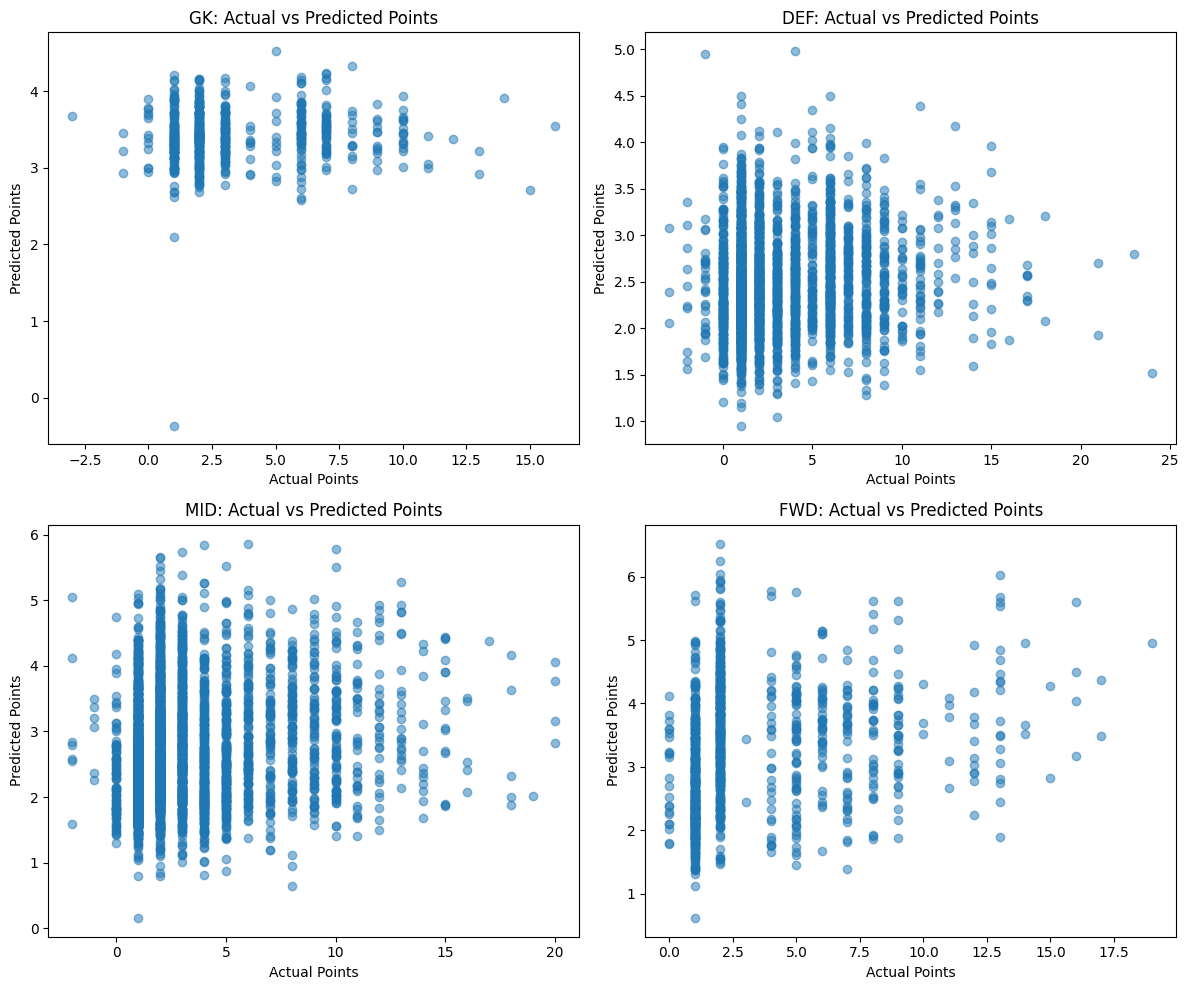

In [ ]:
# create object for model for each position
model_gk = LinearRegression(fit_intercept = True)
model_def = LinearRegression(fit_intercept = True)
model_mid = LinearRegression(fit_intercept = True)
model_fwd = LinearRegression(fit_intercept = True)

# fit each model with training data
model_gk.fit(X_train_gk_scaled , Y_train_gk)
model_def.fit(X_train_def_scaled , Y_train_def)
model_mid.fit(X_train_mid_scaled , Y_train_mid)
model_fwd.fit(X_train_fwd_scaled , Y_train_fwd)

# see how model predicts test data
f_gk = model_gk.predict(X_test_gk_scaled)
f_def = model_def.predict(X_test_def_scaled)
f_mid = model_mid.predict(X_test_mid_scaled)
f_fwd = model_fwd.predict(X_test_fwd_scaled)

# calculate MSE
mse_gk = mean_squared_error(Y_test_gk, f_gk)
mse_def = mean_squared_error(Y_test_def, f_def)
mse_mid= mean_squared_error(Y_test_mid, f_mid)
mse_fwd = mean_squared_error(Y_test_fwd, f_fwd)
print(f'GK MSE: {mse_gk}')
print(f'DEF MSE: {mse_def}')
print(f'MID MSE: {mse_mid}')
print(f'FWD MSE: {mse_fwd}')

# plot function to show predicted points vs actual points
def plotter(test, pred, position, ax):
  ax.scatter(test, pred, alpha = 0.5)
  ax.set_title(f'{position}: Actual vs Predicted Points')
  ax.set_xlabel('Actual Points')
  ax.set_ylabel('Predicted Points')

# define and plot subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plotter(Y_test_gk, f_gk, 'GK', axes[0, 0])
plotter(Y_test_def, f_def, 'DEF', axes[0, 1])
plotter(Y_test_mid, f_mid, 'MID', axes[1, 0])
plotter(Y_test_fwd, f_fwd, 'FWD', axes[1, 1])

plt.tight_layout()
plt.show()


## Apply Random Forest

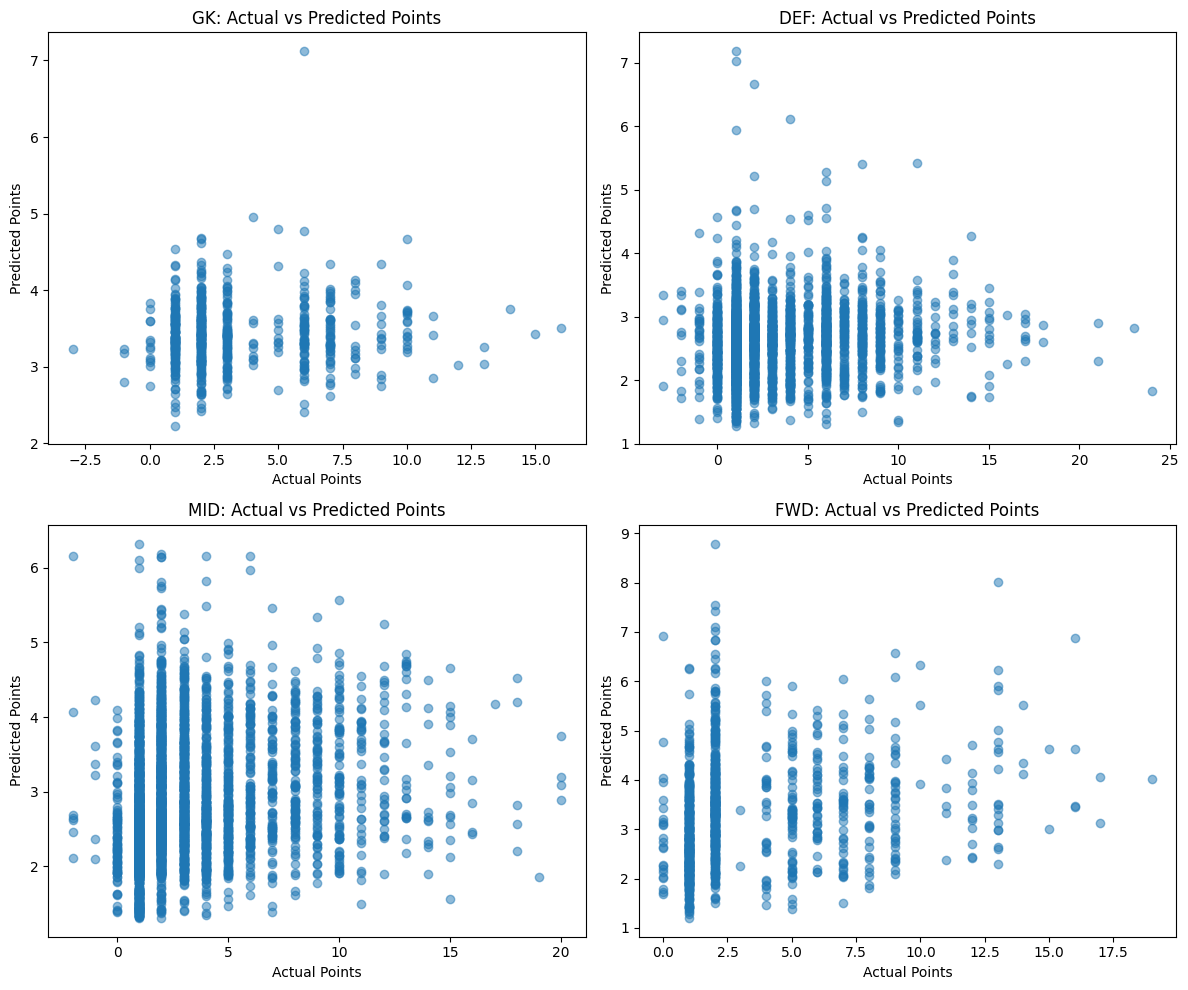

In [ ]:
# create object for model for each position
model_gk = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
model_def = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
model_mid = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
model_fwd = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)

# fit each model with training data
model_gk.fit(X_train_gk, Y_train_gk)
model_def.fit(X_train_def, Y_train_def)
model_mid.fit(X_train_mid, Y_train_mid)
model_fwd.fit(X_train_fwd, Y_train_fwd)

# see how model predicts test data
f_gk = model_gk.predict(X_test_gk)
f_def = model_def.predict(X_test_def)
f_mid = model_mid.predict(X_test_mid)
f_fwd = model_fwd.predict(X_test_fwd)

# define and plot subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plotter(Y_test_gk, f_gk, 'GK', axes[0, 0])
plotter(Y_test_def, f_def, 'DEF', axes[0, 1])
plotter(Y_test_mid, f_mid, 'MID', axes[1, 0])
plotter(Y_test_fwd, f_fwd, 'FWD', axes[1, 1])

plt.tight_layout()
plt.show()

##How Adam wins:
- each position earns points for mins played, then more points based on specific metrics for each position
  - ie. strikers get least points for scoring compared to defense
- look at the difficulty of the team a given team is playing against
  - compare home offense to away defense, home defense to away offense
  - alter captain based on likelyhood of them doing well
  - bring in players that have a string of games with good teams

##When to look for a trade:
- they're getting minutes maybe, but consistently blanking
- not even getting minutes
- look at how many people have transferred a given player


###Notes:
XGBoost - better rand forest

LSTM - future predictions

Current Target Variables:

[Round   |    Stats    |    Min  |    Points Earned   | Target Points ]


[ 1 | ~ | 30 | 1 | 0 ]

[ 2 | ~ | 0 | 0 | 0 ]

[ 3 | ~ | 0 | 0 | 4 ]

[ 4 | ~ | 60 | 4 | 0 ]

[ 5 | ~ | 0 | x | NA ]





XGB GK MSE: 8.079555332340982
XGB DEF MSE: 10.99634086439162
XGB MID MSE: 8.420368657317406
XGB FWD MSE: 10.566330552332479


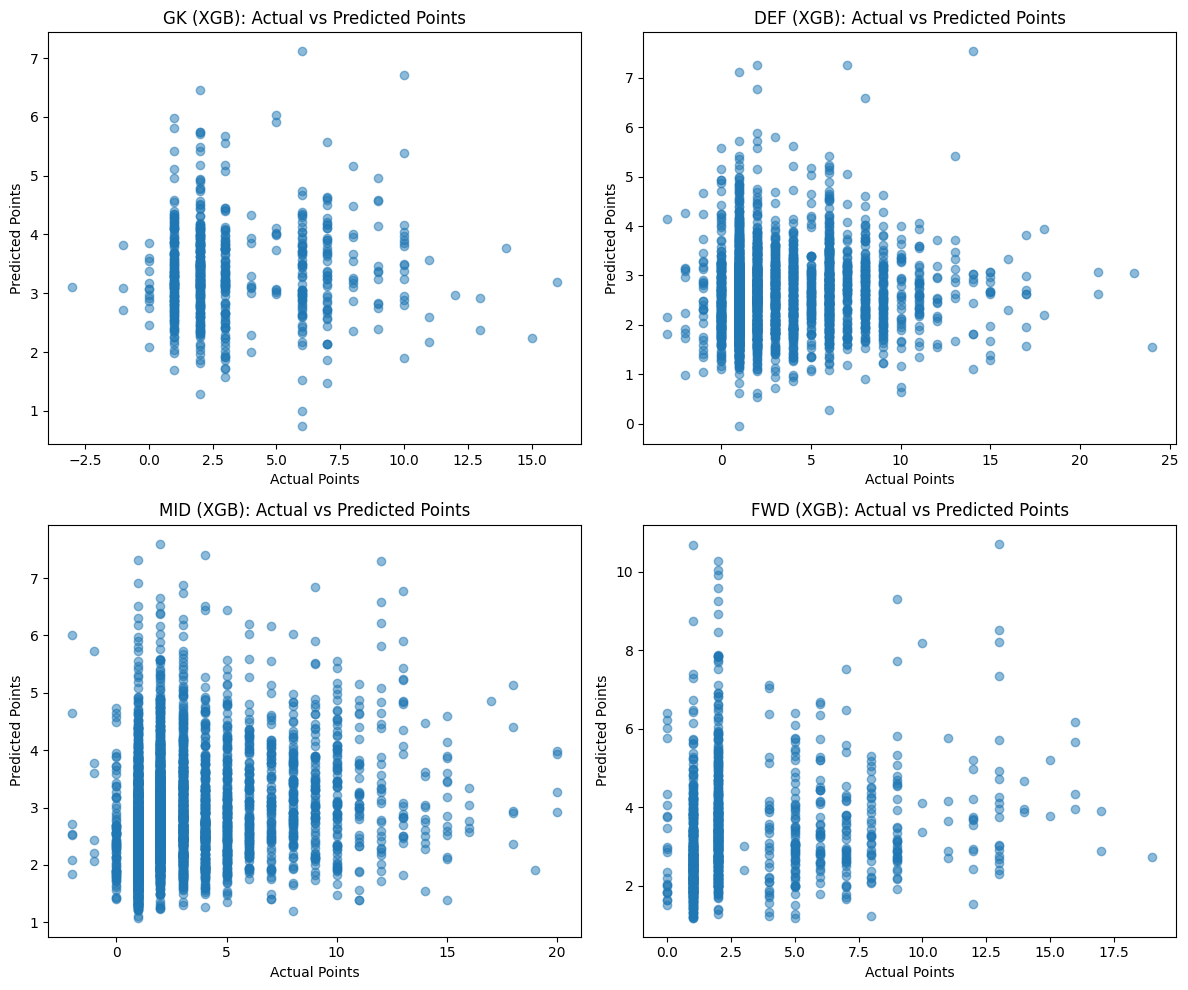

In [ ]:
# XGBoost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# create XGBoost models for each position
model_gk = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
model_def = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
model_mid = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
model_fwd = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)

# fit models (use NON-scaled data like Random Forest)
model_gk.fit(X_train_gk, Y_train_gk)
model_def.fit(X_train_def, Y_train_def)
model_mid.fit(X_train_mid, Y_train_mid)
model_fwd.fit(X_train_fwd, Y_train_fwd)

# predictions
f_gk = model_gk.predict(X_test_gk)
f_def = model_def.predict(X_test_def)
f_mid = model_mid.predict(X_test_mid)
f_fwd = model_fwd.predict(X_test_fwd)

# calculate MSE
mse_gk = mean_squared_error(Y_test_gk, f_gk)
mse_def = mean_squared_error(Y_test_def, f_def)
mse_mid = mean_squared_error(Y_test_mid, f_mid)
mse_fwd = mean_squared_error(Y_test_fwd, f_fwd)

print(f'XGB GK MSE: {mse_gk}')
print(f'XGB DEF MSE: {mse_def}')
print(f'XGB MID MSE: {mse_mid}')
print(f'XGB FWD MSE: {mse_fwd}')

# plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plotter(Y_test_gk, f_gk, 'GK (XGB)', axes[0, 0])
plotter(Y_test_def, f_def, 'DEF (XGB)', axes[0, 1])
plotter(Y_test_mid, f_mid, 'MID (XGB)', axes[1, 0])
plotter(Y_test_fwd, f_fwd, 'FWD (XGB)', axes[1, 1])

plt.tight_layout()
plt.show()



#LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Initialize the Scalers
# We need separate scalers for each position's X and Y
positions = ['gk', 'def', 'mid', 'fwd']
scalers_x = {pos: MinMaxScaler() for pos in positions}
scalers_y = {pos: MinMaxScaler() for pos in positions}
models = {}
results = {}

# Define Architecture (Optimized with Tanh for stability)
def build_lstm(input_shape):
    model = Sequential([
        LSTM(128, activation='relu', input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Train and Predict
def process_position(pos_name, X_train, Y_train, X_test, Y_test):
    # Scale X and Y
    X_train_s = scalers_x[pos_name].fit_transform(X_train)
    X_test_s = scalers_x[pos_name].transform(X_test)
    Y_train_s = scalers_y[pos_name].fit_transform(Y_train.reshape(-1, 1))

    # Reshape X to 3D [samples, time_steps, features]
    X_train_3d = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
    X_test_3d = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))

    # Build and Fit
    model = build_lstm((X_train_3d.shape[1], X_train_3d.shape[2]))
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    model.fit(X_train_3d, Y_train_s, epochs=100, batch_size=32,
              validation_split=0.1, callbacks=[early_stop], verbose=0)

    # Predict and Inverse Scale
    preds_s = model.predict(X_test_3d)
    preds = scalers_y[pos_name].inverse_transform(preds_s)

    mse = mean_squared_error(Y_test, preds)
    return model, preds, mse

# Run all Positions
# Assuming your variables are named X_train_gk, Y_train_gk, etc.
models['gk'], f_gk_lstm, mse_gk = process_position('gk', X_train_gk, Y_train_gk, X_test_gk, Y_test_gk)
models['def'], f_def_lstm, mse_def = process_position('def', X_train_def, Y_train_def, X_test_def, Y_test_def)
models['mid'], f_mid_lstm, mse_mid = process_position('mid', X_train_mid, Y_train_mid, X_test_mid, Y_test_mid)
models['fwd'], f_fwd_lstm, mse_fwd = process_position('fwd', X_train_fwd, Y_train_fwd, X_test_fwd, Y_test_fwd)

# Print Results
print(f'LSTM GK MSE: {mse_gk}')
print(f'LSTM DEF MSE: {mse_def}')
print(f'LSTM MID MSE: {mse_mid}')
print(f'LSTM FWD MSE: {mse_fwd}')


'''
Lin Reg Stats
GK MSE: 7.654054899043312
DEF MSE: 10.67083020956918
MID MSE: 8.391275581057647
FWD MSE: 9.432364224975663
'''

'''
LSTM Stats (128 tanh, 64 tanh, 32 relu)
LSTM GK MSE: 7.60944130016331
LSTM DEF MSE: 10.990386618179105
LSTM MID MSE: 8.284601805149908
LSTM FWD MSE: 9.473577112942984
'''

'''
LSTM Stats (128 relu, 64 relu, 32 relu)
LSTM GK MSE: 7.578839150635541
LSTM DEF MSE: 10.71256886224765
LSTM MID MSE: 8.25569868441721
LSTM FWD MSE: 9.426405947319159
'''

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
LSTM GK MSE: 7.639198170144093
LSTM DEF MSE: 10.831331097215223
LSTM MID MSE: 8.456340868461195
LSTM FWD MSE: 9.621268494765438


'\nLSTM Stats (128 relu, 64 relu, 32 relu)\nLSTM GK MSE: 7.578839150635541\nLSTM DEF MSE: 10.71256886224765\nLSTM MID MSE: 8.25569868441721\nLSTM FWD MSE: 9.426405947319159\n'

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class ManualFeatureWeighting(Layer):
    def __init__(self, weights_list, **kwargs):
        super(ManualFeatureWeighting, self).__init__(**kwargs)
        # Convert the list to a tensor of shape (features,)
        self.manual_weights = tf.constant(weights_list, dtype='float32')

    def call(self, inputs):
        # inputs: (batch, 1, features)
        # weights: (features,)
        # Broadcasting handles the multiplication across the feature dimension
        return inputs * self.manual_weights

#------------------------------------------------------------------------------


# Core 20 features (indices 0-19)
core_features = [
    'avg_assists_5gws', 'avg_bonus_5gws', 'avg_bps_5gws', 'avg_creativity_5gws',
    'avg_expected_assists_5gws', 'avg_expected_goal_involvements_5gws',
    'avg_expected_goals_5gws', 'avg_goals_scored_5gws', 'avg_ict_index_5gws',
    'avg_influence_5gws', 'avg_minutes_5gws', 'avg_own_goals_5gws',
    'avg_penalties_missed_5gws', 'avg_red_cards_5gws', 'avg_starts_5gws',
    'avg_total_points_5gws', 'avg_yellow_cards_5gws', 'selected',
    'team_a_score', 'team_h_score'
]

# Helper to generate weight lists
def get_weight_list(num_features, custom_dict):
    # Start with 1.0 for everything
    weights = [1.0] * num_features
    # Map custom weights to the first 20 core features
    for i, name in enumerate(core_features):
        if name in custom_dict:
            weights[i] = custom_dict[name]
    return weights

# Assign weights based on position needs
# Midfielder weights (29 features total)
mid_weights = get_weight_list(23, {
    'avg_expected_goal_involvements_5gws': 3.0,
    'avg_total_points_5gws': 2.0,
    'avg_creativity_5gws': 1.5
})

# Goalkeeper weights (24 features total)
gk_weights = get_weight_list(18, {
    'avg_bps_5gws': 3.0,
    'avg_influence_5gws': 2.0,
    'avg_total_points_5gws': 2.5
})







In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Attention, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Initialize Scalers
positions = ['gk', 'def', 'mid', 'fwd']
scalers_x = {pos: MinMaxScaler() for pos in positions}
scalers_y = {pos: MinMaxScaler() for pos in positions}
models = {}

# Define a weight list that matches the number of features in the X_train for that specific position
class ManualFeatureWeighting(Layer):
    def __init__(self, weights_list, **kwargs):
        super(ManualFeatureWeighting, self).__init__(**kwargs)
        self.manual_weights = tf.constant(weights_list, dtype='float32')

    def call(self, inputs):
        return inputs * self.manual_weights

# Added custom_weights as a parameter with a default
def build_lstm_with_attention(input_shape, custom_weights=None):
    # If no weights provided, default to all ones (no weighting)
    if custom_weights is None:
        custom_weights = [1.0] * input_shape[1]

    inputs = Input(shape=input_shape)

    # Pass the weights into the custom layer
    weighted_inputs = ManualFeatureWeighting(custom_weights)(inputs)

    # LSTM Layers
    lstm_out = LSTM(128, activation='relu', return_sequences=True)(weighted_inputs)
    lstm_out = Dropout(0.2)(lstm_out)

    query = LSTM(64, activation='relu', return_sequences=True)(lstm_out)
    query = Dropout(0.2)(query)

    att_out = Attention()([query, query])

    query_last = query[:, -1, :]
    att_last = att_out[:, -1, :]

    combined = Concatenate()([query_last, att_last])
    dense1 = Dense(32, activation='relu')(combined)
    outputs = Dense(1)(dense1)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

#------------------------------------------------------------------------------


# Training call for MID
model_mid = build_lstm_with_attention(
    input_shape=(1, 23)
)

# Training call for GK
model_gk = build_lstm_with_attention(
    input_shape=(1, 18),
    custom_weights=gk_weights
)


# Train and Predict Helper
def process_position(pos_name, X_train, Y_train, X_test, Y_test, weights=None):
    # Scale
    X_train_s = scalers_x[pos_name].fit_transform(X_train)
    X_test_s = scalers_x[pos_name].transform(X_test)
    Y_train_s = scalers_y[pos_name].fit_transform(Y_train.reshape(-1, 1))

    # Reshape to 3D
    X_train_3d = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
    X_test_3d = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))

    # Build and Fit
    model = build_lstm_with_attention((X_train_3d.shape[1], X_train_3d.shape[2]), custom_weights=weights)
    early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

    model.fit(X_train_3d, Y_train_s, epochs=100, batch_size=32,
              validation_split=0.1, callbacks=[early_stop], verbose=0)

    # Predict and Inverse Scale
    preds_s = model.predict(X_test_3d)
    preds = scalers_y[pos_name].inverse_transform(preds_s)

    mse = mean_squared_error(Y_test, preds)
    return model, preds, mse

# Run all Positions
models['gk'], f_gk_lstm, mse_gk = process_position('gk', X_train_gk, Y_train_gk, X_test_gk, Y_test_gk)
models['def'], f_def_lstm, mse_def = process_position('def', X_train_def, Y_train_def, X_test_def, Y_test_def)
models['mid'], f_mid_lstm, mse_mid = process_position('mid', X_train_mid, Y_train_mid, X_test_mid, Y_test_mid)
models['fwd'], f_fwd_lstm, mse_fwd = process_position('fwd', X_train_fwd, Y_train_fwd, X_test_fwd, Y_test_fwd)

print(f'Attention LSTM GK MSE: {mse_gk}')
print(f'Attention LSTM DEF MSE: {mse_def}')
print(f'Attention LSTM MID MSE: {mse_mid}')
print(f'Attention LSTM FWD MSE: {mse_fwd}')

'''
LSTM GK MSE: 7.577017261827677
LSTM DEF MSE: 10.994275056564645
LSTM MID MSE: 8.362875229275238
LSTM FWD MSE: 9.502305758170344
'''
'''
Attention LSTM GK MSE: 7.5286475513992555
Attention LSTM DEF MSE: 10.617797669806615
Attention LSTM MID MSE: 8.24118097424023
Attention LSTM FWD MSE: 9.450797838047025
'''

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Attention LSTM GK MSE: 7.569744614795204
Attention LSTM DEF MSE: 10.797567089843344
Attention LSTM MID MSE: 8.303263746409959
Attention LSTM FWD MSE: 9.523956805616471


'\nAttention LSTM GK MSE: 7.5286475513992555\nAttention LSTM DEF MSE: 10.617797669806615\nAttention LSTM MID MSE: 8.24118097424023\nAttention LSTM FWD MSE: 9.450797838047025\n'

#LSTM with manual weights

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Input, LSTM, Dense, Dropout, Attention, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Custom Layer
class ManualFeatureWeighting(Layer):
    def __init__(self, weights_list, **kwargs):
        super(ManualFeatureWeighting, self).__init__(**kwargs)
        self.manual_weights = tf.constant(weights_list, dtype='float32')

    def call(self, inputs):
        return inputs * self.manual_weights

# Updated position-specific feature map
feature_map = {
    'fwd': [
       'avg_assists_5gws', 'avg_bonus_5gws', 'avg_bps_5gws',
       'avg_creativity_5gws', 'avg_expected_assists_5gws',
       'avg_expected_goal_involvements_5gws', 'avg_expected_goals_5gws',
       'avg_goals_scored_5gws', 'avg_ict_index_5gws', 'avg_influence_5gws',
       'avg_minutes_5gws', 'avg_own_goals_5gws', 'avg_penalties_missed_5gws',
       'avg_red_cards_5gws', 'avg_starts_5gws', 'avg_total_points_5gws',
       'avg_yellow_cards_5gws', 'was_home', 'fixture_difficulty'
    ],
    'mid': [
       'avg_assists_5gws', 'avg_bonus_5gws', 'avg_bps_5gws',
       'avg_clean_sheets_5gws', 'avg_creativity_5gws',
       'avg_expected_assists_5gws', 'avg_expected_goal_involvements_5gws',
       'avg_expected_goals_5gws', 'avg_expected_goals_conceded_5gws',
       'avg_goals_conceded_5gws', 'avg_goals_scored_5gws',
       'avg_ict_index_5gws', 'avg_influence_5gws', 'avg_minutes_5gws',
       'avg_own_goals_5gws', 'avg_penalties_missed_5gws', 'avg_red_cards_5gws',
       'avg_starts_5gws', 'avg_threat_5gws', 'avg_total_points_5gws',
       'avg_yellow_cards_5gws', 'was_home', 'fixture_difficulty'
    ],
    'def': [
       'avg_assists_5gws', 'avg_bonus_5gws', 'avg_bps_5gws',
       'avg_clean_sheets_5gws', 'avg_creativity_5gws',
       'avg_expected_assists_5gws', 'avg_expected_goal_involvements_5gws',
       'avg_expected_goals_5gws', 'avg_expected_goals_conceded_5gws',
       'avg_goals_conceded_5gws', 'avg_goals_scored_5gws',
       'avg_ict_index_5gws', 'avg_influence_5gws', 'avg_minutes_5gws',
       'avg_own_goals_5gws', 'avg_penalties_missed_5gws', 'avg_red_cards_5gws',
       'avg_starts_5gws', 'avg_threat_5gws', 'avg_total_points_5gws',
       'avg_yellow_cards_5gws', 'was_home', 'fixture_difficulty'
    ],
    'gk': [
       'avg_bonus_5gws', 'avg_bps_5gws', 'avg_clean_sheets_5gws',
       'avg_expected_goals_conceded_5gws', 'avg_goals_conceded_5gws',
       'avg_ict_index_5gws', 'avg_influence_5gws', 'avg_minutes_5gws',
       'avg_own_goals_5gws', 'avg_penalties_saved_5gws', 'avg_red_cards_5gws',
       'avg_saves_5gws', 'avg_starts_5gws', 'avg_threat_5gws',
       'avg_total_points_5gws', 'avg_yellow_cards_5gws', 'was_home',
       'fixture_difficulty'
    ]
}

# Generate position-specific weight lists
def get_weight_list(pos_name, num_features, custom_dict):
    weights = [1.0] * num_features
    # Use the specific feature list for this position
    current_feature_list = feature_map[pos_name]
    for i, name in enumerate(current_feature_list):
        if name in custom_dict:
            weights[i] = custom_dict[name]
    return weights

# LSTM with attention
def build_lstm_with_attention(input_shape, custom_weights):
    inputs = Input(shape=input_shape)
    weighted_inputs = ManualFeatureWeighting(custom_weights)(inputs)

    lstm_out = LSTM(128, activation='relu', return_sequences=True)(weighted_inputs)
    lstm_out = Dropout(0.2)(lstm_out)

    query = LSTM(64, activation='relu', return_sequences=True)(lstm_out)
    query = Dropout(0.2)(query)

    att_out = Attention()([query, query])

    query_last = query[:, -1, :]
    att_last = att_out[:, -1, :]

    combined = Concatenate()([query_last, att_last])

    dense1 = Dense(32, activation='relu')(combined)
    outputs = Dense(1)(dense1)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

# Manual weights (contains some old features)
pos_weights_map = {
    'gk': get_weight_list('gk', 18, {'avg_clean_sheets_5gws': 3.0, 'avg_expected_goals_conceded_5gws': 2.5, 'avg_minutes_5gws': 3.0, 'avg_saves_5gws': 3.0, 'avg_total_points_5gws': 2.0, 'transfers_balance': 2.0,
        'transfers_in': 2.0, 'transfers_out': 2.0}),
    'def': get_weight_list('def', 23, {'avg_minutes_5gws': 3.0, 'avg_expected_goals_conceded_5gws': 3.0, 'avg_total_points_5gws': 2.0, 'avg_influence_5gws': 2.5, 'transfers_balance': 2.0,
        'transfers_in': 2.0, 'transfers_out': 2.0}),
    'mid': get_weight_list('mid', 23, {'avg_assists_5gws': 0.83, 'avg_bonus_5gws': 3.48, 'avg_bps_5gws': 1.32, 'avg_clean_sheets_5gws': 3.54,
'avg_creativity_5gws': 0.59, 'avg_expected_assists_5gws': 3.37, 'avg_expected_goal_involvements_5gws': 1.02,
'avg_expected_goals_5gws': 3.83, 'avg_expected_goals_conceded_5gws': 2.83, 'avg_goals_conceded_5gws': 1.17,
'avg_goals_scored_5gws': 3.95, 'avg_ict_index_5gws': 1.47, 'avg_influence_5gws': 3.18,
'avg_minutes_5gws': 3.18, 'avg_own_goals_5gws': 1.57, 'avg_penalties_missed_5gws': 0.79,
'avg_red_cards_5gws': 2.99, 'avg_starts_5gws': 1.53, 'avg_threat_5gws': 1.05, 'avg_total_points_5gws': 1.46,
'avg_yellow_cards_5gws': 3.51, 'selected': 3.15, 'team_a_score': 2.12, 'team_h_score': 3.01,
'transfers_balance': 3.64, 'transfers_in': 1.1, 'transfers_out': 3.25, 'value': 1.59, 'was_home': 1.58}),
    'fwd': get_weight_list('fwd', 19, {'avg_minutes_5gws': 3.0, 'avg_expected_goals_5gws': 3.0, 'avg_expected_assists_5gws': 3.0, 'avg_total_points_5gws': 2.0, 'transfers_balance': 2.0,
        'transfers_in': 2.0, 'transfers_out': 2.0})
}

# Train and predict
scalers_x = {pos: MinMaxScaler() for pos in pos_weights_map.keys()}
scalers_y = {pos: MinMaxScaler() for pos in pos_weights_map.keys()}

def process_position(pos_name, X_train, Y_train, X_test, Y_test):
    X_train_s = scalers_x[pos_name].fit_transform(X_train)
    X_test_s = scalers_x[pos_name].transform(X_test)
    Y_train_s = scalers_y[pos_name].fit_transform(Y_train.reshape(-1, 1))

    X_train_3d = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
    X_test_3d = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))

    current_weights = pos_weights_map[pos_name]
    model = build_lstm_with_attention((X_train_3d.shape[1], X_train_3d.shape[2]), current_weights)

    early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
    model.fit(X_train_3d, Y_train_s, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=0)

    preds_s = model.predict(X_test_3d)
    preds = scalers_y[pos_name].inverse_transform(preds_s)
    mse = mean_squared_error(Y_test, preds)
    return model, preds, mse

# Execute
models = {}
models['gk'], f_gk_lstm, mse_gk = process_position('gk', X_train_gk, Y_train_gk, X_test_gk, Y_test_gk)
models['def'], f_def_lstm, mse_def = process_position('def', X_train_def, Y_train_def, X_test_def, Y_test_def)
models['mid'], f_mid_lstm, mse_mid = process_position('mid', X_train_mid, Y_train_mid, X_test_mid, Y_test_mid)
models['fwd'], f_fwd_lstm, mse_fwd = process_position('fwd', X_train_fwd, Y_train_fwd, X_test_fwd, Y_test_fwd)

print(f"Results:\nGK MSE: {mse_gk}\nDEF MSE: {mse_def}\nMID MSE: {mse_mid}\nFWD MSE: {mse_fwd}")

'''
Results:
GK MSE: 7.571356267047833
DEF MSE: 10.749439604100656
MID MSE: 8.232705768848371
FWD MSE: 9.412383131663232
'''


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Results:
GK MSE: 7.51767650601723
DEF MSE: 10.74854451619438
MID MSE: 8.40097283898831
FWD MSE: 9.666782816594846


'\nResults:\nGK MSE: 7.571356267047833\nDEF MSE: 10.749439604100656\nMID MSE: 8.232705768848371\nFWD MSE: 9.412383131663232\n'

#LSTM with manual weights from grid search optimization

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Input, LSTM, Dense, Dropout, Attention, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import itertools

# Custom layer
class ManualFeatureWeighting(Layer):
    def __init__(self, weights_list, **kwargs):
        super(ManualFeatureWeighting, self).__init__(**kwargs)
        self.manual_weights = tf.constant(weights_list, dtype='float32')

    def call(self, inputs):
        return inputs * self.manual_weights

# LSTM with attention + custom weights
def build_lstm_with_attention(input_shape, custom_weights):
    inputs = Input(shape=input_shape)
    weighted_inputs = ManualFeatureWeighting(custom_weights)(inputs)

    # LSTM Layers
    lstm_out = LSTM(128, activation='relu', return_sequences=True)(weighted_inputs)
    lstm_out = Dropout(0.2)(lstm_out)
    query = LSTM(64, activation='relu', return_sequences=True)(lstm_out)
    query = Dropout(0.2)(query)

    # Attention
    att_out = Attention()([query, query])
    query_last = query[:, -1, :]
    att_last = att_out[:, -1, :]

    combined = Concatenate()([query_last, att_last])
    dense1 = Dense(32, activation='relu')(combined)
    outputs = Dense(1)(dense1)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

# Train and predict - with weight list
def process_position(pos_name, X_train, Y_train, X_test, Y_test, weight_list):
    # Scale
    sx, sy = MinMaxScaler(), MinMaxScaler()
    X_train_s = sx.fit_transform(X_train)
    X_test_s = sx.transform(X_test)
    Y_train_s = sy.fit_transform(Y_train.reshape(-1, 1))

    # Reshape to 3D
    X_train_3d = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
    X_test_3d = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))

    # Build (passing the required weight_list)
    model = build_lstm_with_attention((X_train_3d.shape[1], X_train_3d.shape[2]), weight_list)

    early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
    model.fit(X_train_3d, Y_train_s, epochs=100, batch_size=32,
              validation_split=0.1, callbacks=[early_stop], verbose=0)

    preds_s = model.predict(X_test_3d)
    preds = sy.inverse_transform(preds_s)
    mse = mean_squared_error(Y_test, preds)
    return model, preds, mse

# Sequential grid search function
def find_best_weights_sequential(pos_name, X_train, Y_train, X_test, Y_test, options=[0.5, 1.0, 2.0, 3.0]):
    num_features = X_train.shape[1]
    best_weights = [1.0] * num_features

    print(f"--- Starting optimization for {pos_name} ---")
    for i in range(num_features):
        best_mse_for_feature = float('inf')
        best_val_for_feature = 1.0

        for val in options:
            current_test_weights = best_weights.copy()
            current_test_weights[i] = val
            # Quick train for search
            _, _, mse = process_position(pos_name, X_train, Y_train, X_test, Y_test, current_test_weights)

            if mse < best_mse_for_feature:
                best_mse_for_feature = mse
                best_val_for_feature = val

        best_weights[i] = best_val_for_feature
        print(f"Feature {i} best weight: {best_val_for_feature} (MSE: {best_mse_for_feature:.4f})")

    return best_weights

# Run search
best_gk_weights = find_best_weights_sequential('gk', X_train_gk, Y_train_gk, X_test_gk, Y_test_gk)

# Run a final model with fixed weights:
# models['gk'], f_gk_lstm, mse_gk = process_position('gk', X_train_gk, Y_train_gk, X_test_gk, Y_test_gk, best_gk_weights)


--- Starting optimization for gk ---
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Feature 0 best weight: 1.0 (MSE: 7.5723)


KeyboardInterrupt: 

In [ ]:

pos_weights_map = {
    'gk': get_weight_list('gk', 24, {'avg_clean_sheets_5gws': 3.0, 'avg_expected_goals_conceded_5gws': 2.5, 'avg_minutes_5gws': 3.0, 'avg_saves_5gws': 3.0, 'avg_total_points_5gws': 2.0, 'transfers_balance': 2.0,
        'transfers_in': 2.0, 'transfers_out': 2.0}),
    'def': get_weight_list('def', 29, {'avg_minutes_5gws': 3.0, 'avg_expected_goals_conceded_5gws': 3.0, 'avg_total_points_5gws': 2.0, 'avg_influence_5gws': 2.5, 'transfers_balance': 2.0,
        'transfers_in': 2.0, 'transfers_out': 2.0}),
    'mid': get_weight_list('mid', 29, {'avg_assists_5gws': 2.0, 'avg_bonus_5gws': 2.0, 'avg_bps_5gws': 0.5, 'avg_clean_sheets_5gws': 0.5,
'avg_creativity_5gws': 2.0, 'avg_expected_assists_5gws': 2.0, 'avg_expected_goal_involvements_5gws': 0.5,
'avg_expected_goals_5gws': 0.5, 'avg_expected_goals_conceded_5gws': 3.0, 'avg_goals_conceded_5gws': 3.0,
'avg_goals_scored_5gws': 0.5, 'avg_ict_index_5gws': 1.0, 'avg_influence_5gws': 0.5,
'avg_minutes_5gws': 1.0, 'avg_own_goals_5gws': 2.0, 'avg_penalties_missed_5gws': 2.0,
'avg_red_cards_5gws': 1.0, 'avg_starts_5gws': 3.0, 'avg_threat_5gws': 0.5, 'avg_total_points_5gws': 3.0,
'avg_yellow_cards_5gws': 3.0, 'selected': 0.5, 'team_a_score': 1.0, 'team_h_score': 0.5,
'transfers_balance': 1.0, 'transfers_in': 3.0, 'transfers_out': 2.0, 'value': 0.5, 'was_home': 2.0}),
    'fwd': get_weight_list('fwd', 25, {'avg_minutes_5gws': 3.0, 'avg_expected_goals_5gws': 3.0, 'avg_expected_assists_5gws': 3.0, 'avg_total_points_5gws': 2.0, 'transfers_balance': 2.0,
        'transfers_in': 2.0, 'transfers_out': 2.0})
}

'''
MID SEARCH

'avg_assists_5gws': 2.0, 'avg_bonus_5gws': 2.0, 'avg_bps_5gws': 0.5, 'avg_clean_sheets_5gws': 0.5,
'avg_creativity_5gws': 2.0, 'avg_expected_assists_5gws': 2.0, 'avg_expected_goal_involvements_5gws': 0.5,
'avg_expected_goals_5gws': 0.5, 'avg_expected_goals_conceded_5gws': 3.0, 'avg_goals_conceded_5gws': 3.0,
'avg_goals_scored_5gws': 0.5, 'avg_ict_index_5gws': 1.0, 'avg_influence_5gws': 0.5,
'avg_minutes_5gws': 1.0, 'avg_own_goals_5gws': 2.0, 'avg_penalties_missed_5gws': 2.0,
'avg_red_cards_5gws': 1.0, 'avg_starts_5gws': 3.0, 'avg_threat_5gws': 0.5, 'avg_total_points_5gws': 3.0,
'avg_yellow_cards_5gws': 3.0, 'selected': 0.5, 'team_a_score': 1.0, 'team_h_score': 0.5,
'transfers_balance': 1.0, 'transfers_in': 3.0, 'transfers_out': 2.0, 'value': 0.5, 'was_home': 2.0
'''

'''
MID SEARCH

Feature 0 (avg_assists_5gws): Optimized to 2.0 | MSE: 8.2403
Feature 1 (avg_bonus_5gws): Optimized to 2.0 | MSE: 8.2286
Feature 2 (avg_bps_5gws): Optimized to 0.5 | MSE: 8.2164
Feature 3 (avg_clean_sheets_5gws): Optimized to 0.5 | MSE: 8.2166
Feature 4 (avg_creativity_5gws): Optimized to 2.0 | MSE: 8.2346
Feature 5 (avg_expected_assists_5gws): Optimized to 2.0 | MSE: 8.2775
Feature 6 (avg_expected_goal_involvements_5gws): Optimized to 0.5 | MSE: 8.2474
Feature 7 (avg_expected_goals_5gws): Optimized to 0.5 | MSE: 8.2395
Feature 8 (avg_expected_goals_conceded_5gws): Optimized to 3.0 | MSE: 8.1247
Feature 9 (avg_goals_conceded_5gws): Optimized to 3.0 | MSE: 8.2320
Feature 10 (avg_goals_scored_5gws): Optimized to 0.5 | MSE: 8.1716
Feature 11 (avg_ict_index_5gws): Optimized to 1.0 | MSE: 8.2370
Feature 12 (avg_influence_5gws): Optimized to 0.5 | MSE: 8.2178
Feature 13 (avg_minutes_5gws): Optimized to 1.0 | MSE: 8.2298
Feature 14 (avg_own_goals_5gws): Optimized to 2.0 | MSE: 8.1984
Feature 15 (avg_penalties_missed_5gws): Optimized to 2.0 | MSE: 8.2084
Feature 16 (avg_red_cards_5gws): Optimized to 1.0 | MSE: 8.2148
Feature 17 (avg_starts_5gws): Optimized to 3.0 | MSE: 8.1816
Feature 18 (avg_threat_5gws): Optimized to 0.5 | MSE: 8.1794
Feature 19 (avg_total_points_5gws): Optimized to 3.0 | MSE: 8.2543
Feature 20 (avg_yellow_cards_5gws): Optimized to 3.0 | MSE: 8.1801
Feature 21 (selected): Optimized to 0.5 | MSE: 8.1931
Feature 22 (team_a_score): Optimized to 1.0 | MSE: 8.1679
Feature 23 (team_h_score): Optimized to 0.5 | MSE: 8.1693
Feature 24 (transfers_balance): Optimized to 1.0 | MSE: 8.2207
Feature 25 (transfers_in): Optimized to 3.0 | MSE: 8.2322
Feature 26 (transfers_out): Optimized to 2.0 | MSE: 8.2279
Feature 27 (value): Optimized to 0.5 | MSE: 8.2129
Feature 28 (was_home): Optimized to 2.0 | MSE: 8.2395
'''


'\nMID SEARCH\n\nFeature 0 (avg_assists_5gws): Optimized to 2.0 | MSE: 8.2403\nFeature 1 (avg_bonus_5gws): Optimized to 2.0 | MSE: 8.2286\nFeature 2 (avg_bps_5gws): Optimized to 0.5 | MSE: 8.2164\nFeature 3 (avg_clean_sheets_5gws): Optimized to 0.5 | MSE: 8.2166\nFeature 4 (avg_creativity_5gws): Optimized to 2.0 | MSE: 8.2346\nFeature 5 (avg_expected_assists_5gws): Optimized to 2.0 | MSE: 8.2775\nFeature 6 (avg_expected_goal_involvements_5gws): Optimized to 0.5 | MSE: 8.2474\nFeature 7 (avg_expected_goals_5gws): Optimized to 0.5 | MSE: 8.2395\nFeature 8 (avg_expected_goals_conceded_5gws): Optimized to 3.0 | MSE: 8.1247\nFeature 9 (avg_goals_conceded_5gws): Optimized to 3.0 | MSE: 8.2320\nFeature 10 (avg_goals_scored_5gws): Optimized to 0.5 | MSE: 8.1716\nFeature 11 (avg_ict_index_5gws): Optimized to 1.0 | MSE: 8.2370\nFeature 12 (avg_influence_5gws): Optimized to 0.5 | MSE: 8.2178\nFeature 13 (avg_minutes_5gws): Optimized to 1.0 | MSE: 8.2298\nFeature 14 (avg_own_goals_5gws): Optimized

#LSTM with manual weights from random search optimization

In [ ]:
# Generate with randomized weights to find optimal feature weights
# Increase n_iter as desired
def random_weight_search(pos_name, X_train, Y_train, X_test, Y_test, n_iter=10):
    num_feats = X_train.shape[1]
    best_overall_mse = float('inf')
    best_overall_weights = None

    print(f"--- Starting Randomized Search for {pos_name.upper()} ({n_iter} iterations) ---")

    for i in range(n_iter):
        # Generate a random weight for EVERY feature simultaneously
        # Sample between 0.5 (low importance) and 4.0 (high importance)
        random_weights = [round(random.uniform(0.5, 4.0), 2) for _ in range(num_feats)]

        # Evaluate the performance of this entire set of weights
        mse = process_position(pos_name, X_train, Y_train, X_test, Y_test, random_weights)[2]

        if mse < best_overall_mse:
            best_overall_mse = mse
            best_overall_weights = random_weights
            print(f"Iteration {i}: New Best Overall MSE = {mse:.4f}")

    return best_overall_weights, best_overall_mse

# Run for the MID position
optimized_mid_weights, mid_mse = random_weight_search('mid', X_train_mid, Y_train_mid, X_test_mid, Y_test_mid)
#optimized_fwd_weights, fwd_mse = random_weight_search('fwd', X_train_fwd, Y_train_fwd, X_test_fwd, Y_test_fwd)





--- Starting Randomized Search for MID (10 iterations) ---
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Iteration 0: New Best Overall MSE = 8.2976


KeyboardInterrupt: 

In [ ]:
# Iteration 81: New Best Overall MSE = 8.1451
# [0.83, 3.48, 1.32, 3.54, 0.59, 3.37, 1.02, 3.83, 2.83, 1.17, 3.95, 1.47, 3.18, 3.18, 1.57, 0.79, 2.99, 1.53, 1.05, 1.46, 3.51, 3.15, 2.12, 3.01, 3.64, 1.1, 3.25, 1.59, 1.58]
best_mid_weights = optimized_mid_weights
print(best_mid_weights)

In [ ]:
print(optimized_mid_weights)